# Figures 1 and 2 — *Campylobacter* case

This notebook regenerates the two manuscript figures exactly as in the Results section, sized for the 12.2-cm LNCS text width, from the **project bundle zip** (`Campy_case_Bayesian_acceptance_Github…zip`). It does not need Google Drive: upload the zip when prompted (or point `BUNDLE_ZIP` / `BUNDLE_DIR` to it) and run all cells.

* **Section 0 — Load the bundle**: extracts the zip into the Colab session and checks that every input is present.
* **Section 1 — Figure 1**: automatic vs participant-derived scoring (participant scores vs automatic intervals, smallest adaptation creating an NBS, distance to an NBS).
* **Section 2 — Figure 2**: negotiation outcomes and how public statements were perceived by the Bayesian opponent models (two-row layout, panels a–f).

No API calls are made. Every opponent-model state in Fig. 2 is rebuilt exactly from the public priors and checked against the logged calls.

**Files read from the bundle**

| Path in the bundle | Used for |
|---|---|
| `analysis_outputs/participant_score_interval_coverage.csv` | Fig. 1a |
| `analysis_outputs/equilibrium_packages_median_representative.csv` | automatic profile for Fig. 1c |
| `perturbation_outputs/smallest_genuine_nbs_weight_changes.csv`, `balanced_perturbation_results.json` | Fig. 1b–c (automatic); adapted true scores for Fig. 2 |
| `participant_perturbation_outputs/smallest_genuine_nbs_weight_changes.csv`, `balanced_perturbation_results.json`, `participant_original_profile.json` | Fig. 1b–c (participant-derived) |
| `adapted_bayesian_negotiation_outputs/` | Fig. 2 (one folder per run) |
| `public_priors_Campylobacter.json` | opponent-model priors for Fig. 2 (embedded GPT-5.5 priors are used if this file does not reproduce the runs) |

Outputs (PNG at 300 dpi, PDF, CSV tables) are written to `figure_outputs/` and downloaded as one zip at the end.

# Section 0 — Load the bundle

### 0.1 Settings

In [1]:
BUNDLE_ZIP = None          # path to the bundle zip (or a list of zip parts); None = upload prompt in Colab
BUNDLE_DIR = None          # an already extracted bundle folder; takes precedence over BUNDLE_ZIP
EXTRACT_DIR = 'campy_bundle'
OUT_DIR = 'figure_outputs'
PRIORS_FILE = None         # None = public_priors_Campylobacter.json in the bundle (embedded GPT-5.5 priors as fallback)
SEMANTIC_MODEL = 'gpt-5.5'          # --semantic_model of the runs (the evidence cache is keyed by it)
INCLUDE_LAST_STATEMENT = False      # Fig. 2d–f end at the final vote, without the last statement before it
EXCLUDE_NBS_STANCES = True          # NBS rank: ignore statements accepting/rejecting the NBS itself
VIEW_ELEV, VIEW_AZIM = 22, -62      # rotation of the 3D landscape (Fig. 2b)

### 0.2 Upload / extract the bundle and check the inputs

In [3]:
import json, shutil, zipfile
from pathlib import Path

REQUIRED = ['analysis_outputs/participant_score_interval_coverage.csv',
            'analysis_outputs/equilibrium_packages_median_representative.csv',
            'perturbation_outputs/smallest_genuine_nbs_weight_changes.csv',
            'perturbation_outputs/balanced_perturbation_results.json',
            'participant_perturbation_outputs/smallest_genuine_nbs_weight_changes.csv',
            'participant_perturbation_outputs/balanced_perturbation_results.json',
            'participant_perturbation_outputs/participant_original_profile.json',
            'adapted_bayesian_negotiation_outputs']

def find_bundle_root(base):
    hits = [p.parent for p in Path(base).rglob('analysis_outputs') if p.is_dir() and '__MACOSX' not in p.parts]
    if not hits:
        raise SystemExit(f'No analysis_outputs/ folder found under {base}: is this the right zip?')
    return min(hits, key=lambda p: len(p.parts))

if BUNDLE_DIR:
    root = find_bundle_root(BUNDLE_DIR)
else:
    zips = BUNDLE_ZIP if isinstance(BUNDLE_ZIP, (list, tuple)) else ([BUNDLE_ZIP] if BUNDLE_ZIP else [])
    if not zips:
        try:
            from google.colab import files as colab_files
        except ImportError:
            raise SystemExit('Outside Colab, set BUNDLE_ZIP (path to the zip) or BUNDLE_DIR (extracted folder).')
        print('Select the bundle zip (several parts can be selected together):')
        up = Path('uploads'); up.mkdir(exist_ok=True)
        for name, data in colab_files.upload().items():
            (up / name).write_bytes(data)
            zips.append(up / name)
    shutil.rmtree(EXTRACT_DIR, ignore_errors=True)
    for z in zips:
        with zipfile.ZipFile(z) as zf:
            zf.extractall(EXTRACT_DIR)
    root = find_bundle_root(EXTRACT_DIR)

missing = [r for r in REQUIRED if not (root / r).exists()]
if missing:
    raise SystemExit(f'Missing in the bundle {root}: {missing}')
PROJECT_DIR = str(root)
if PRIORS_FILE is None and (root / 'public_priors_Campylobacter.json').exists():
    PRIORS_FILE = root / 'public_priors_Campylobacter.json'
n_runs = sum(1 for p in (root / 'adapted_bayesian_negotiation_outputs').iterdir() if p.is_dir())
print(f'Bundle: {root}   runs: {n_runs}   priors file: {PRIORS_FILE}')

Select the bundle zip (several parts can be selected together):


Saving Campy_case_Bayesian_acceptance_Github-20261009T110223Z-1-001.zip to Campy_case_Bayesian_acceptance_Github-20261009T110223Z-1-001.zip
Bundle: campy_bundle/Campy_case_Bayesian_acceptance_Github   runs: 28   priors file: campy_bundle/Campy_case_Bayesian_acceptance_Github/public_priors_Campylobacter.json


# Section 1 — Figure 1: automatic vs participant-derived scoring

### 1.1 Imports, paths and style

In [4]:
from pathlib import Path
import json, re, itertools, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import blended_transform_factory
PROJECT_DIR = Path(PROJECT_DIR)
AN, AU, PA = (PROJECT_DIR / d for d in ['analysis_outputs', 'perturbation_outputs', 'participant_perturbation_outputs'])
OUT = Path(OUT_DIR); OUT.mkdir(parents=True, exist_ok=True)
THRESHOLD = 65

# Fonts — adjust here. The canvas is 9 in wide and is printed at the 12.2-cm LNCS text width
# (scale ≈ 0.53), so 13.5 pt on the canvas prints at ≈ 7 pt.
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13.5, 'axes.titlesize': 14.5, 'axes.titleweight': 'bold',
                     'axes.labelsize': 13.5, 'xtick.labelsize': 12.5, 'ytick.labelsize': 12.5, 'legend.fontsize': 12.5,
                     'axes.spines.top': False, 'axes.spines.right': False, 'savefig.dpi': 300})
FS = dict(letter=20, title=14.5, tick=12.5, small=12, ann=12.5, leg=12.5)
BLUE, CORAL, GREY, PALE, INK = 'steelblue', 'coral', 'grey', '#9ebbd0', '#222222'
INSIDE, OUTSIDE = '#2ca02c', '#d62728'
DIVERGING = LinearSegmentedColormap.from_list('div', ['#1f4e79', BLUE, '#f2f2f2', CORAL, '#b03a2e'])
SHORT = {'Consumers': 'Cons', 'Food industry': 'FI', 'Food Safety Authorities': 'FSA', 'Environmental NGOs': 'NGOs'}

def letter(fig_or_sub, text, x=0.0, y=1.0):
    fig_or_sub.text(x, y, text, fontsize=FS['letter'], fontweight='bold', va='top', ha='left')

def clean(ax, keep_left=True):
    for s in ('top', 'right') + (() if keep_left else ('left',)):
        ax.spines[s].set_visible(False)

def save(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(OUT / f'{name}.{ext}', bbox_inches='tight', dpi=300)
    print('Saved', OUT / f'{name}.png')

### 1.2 Data and minimum-transfer search

## 2 — Data for Figure 1

The minimum-transfer search (Fig. 1c) enumerates every valid integer re-weighting with at most `CAP` transferred points per stakeholder, using the same rules as Step 8 (100-point budgets, order-preserving integer re-quantisation, frozen zero-weight issues). It takes 3–5 min and is cached in ``OUT_DIR``.

In [5]:
def integer_rescale(source, target_maximum):
    target_maximum = int(target_maximum); old_maximum = int(max(source.values()))
    if old_maximum == 0:
        return {o: 0 for o in source}
    levels = sorted(set(int(x) for x in source.values()))
    mapped = [int(round(l * target_maximum / old_maximum)) for l in levels]
    if levels[0] == 0: mapped[0] = 0
    mapped[-1] = target_maximum
    for i in range(1, len(mapped)): mapped[i] = max(mapped[i], mapped[i - 1] + 1)
    mapped[-1] = target_maximum
    for i in range(len(mapped) - 2, -1, -1): mapped[i] = min(mapped[i], mapped[i + 1] - 1)
    if levels[0] == 0: mapped[0] = 0
    lookup = dict(zip(levels, mapped))
    return {o: int(lookup[int(v)]) for o, v in source.items()}

def reconstruct_profile(package_csv, weights_csv):
    # additive model: within-issue differences come from the package utilities; the best option equals the issue weight
    pk = pd.read_csv(package_csv); w = pd.read_csv(weights_csv)
    names = list(dict.fromkeys(w.stakeholder)); issues = sorted(w.issue.unique())
    parts = pk.package.str.split(', ', expand=True); parts.columns = issues
    prof = {}
    for n in names:
        prof[n] = {}
        for i in issues:
            mask = np.all([parts[j] == parts[j].iloc[0] for j in issues if j != i], axis=0)
            sub = pk[mask].set_index(parts[mask][i])[n]
            weight = int(w[(w.stakeholder == n) & (w.issue == i)].original_weight.iloc[0])
            prof[n][i] = {o: int(round(weight - (sub.max() - v))) for o, v in sub.sort_index().items()}
        u = sum(parts[i].map(prof[n][i]) for i in issues)
        assert np.array_equal(u.to_numpy(), pk[n].round().astype(int).to_numpy()), f'reconstruction failed for {n}'
    return prof

def weight_vectors(tables, cap):
    issues = sorted(tables)
    w0 = np.array([max(tables[i].values()) for i in issues]); active = np.flatnonzero(w0 > 0)
    mins = np.array([max(1, len(set(tables[i].values())) - 1) if w0[k] > 0 else 0 for k, i in enumerate(issues)])
    lo, hi = np.maximum(mins, w0 - cap), w0 + cap
    grids = [np.arange(lo[k], hi[k] + 1) for k in active[:-1]]
    prefix = np.array(np.meshgrid(*grids, indexing='ij')).reshape(len(grids), -1).T
    last = w0[active].sum() - prefix.sum(1); keep = (last >= lo[active[-1]]) & (last <= hi[active[-1]])
    W = np.tile(w0, (int(keep.sum()), 1)); W[:, active[:-1]] = prefix[keep]; W[:, active[-1]] = last[keep]
    t = np.abs(W - w0).sum(1) // 2
    return issues, w0, W[t <= cap], t[t <= cap]

def min_transfer_per_package(tables, target=66, cap=30, chunk=20000):
    issues, w0, W, transfer = weight_vectors(tables, cap)
    opts = {i: sorted(tables[i]) for i in issues}
    packages = list(itertools.product(*(opts[i] for i in issues)))
    lookup = []
    for k, i in enumerate(issues):
        arr = np.zeros((W[:, k].max() + 1, len(opts[i])), dtype=np.int16)
        for v in np.unique(W[:, k]):
            t = integer_rescale(tables[i], int(v)); arr[v] = [t[o] for o in opts[i]]
        lookup.append(arr)
    idx = [np.array([opts[i].index(p[k]) for p in packages]) for k, i in enumerate(issues)]
    best = np.full(len(packages), np.inf)
    for s in range(0, len(W), chunk):
        Wc = W[s:s + chunk]; val = np.zeros((len(Wc), len(packages)), dtype=np.int32)
        for k in range(len(issues)): val += lookup[k][Wc[:, k][:, None], idx[k][None, :]]
        best = np.minimum(best, np.where(val >= target, transfer[s:s + chunk, None], np.inf).min(0))
    return [', '.join(p) for p in packages], best

def first_nbs_quality(profile, package, target=66, cap=30):
    # rebuild the minimum-transfer landscape for `package` and return its NBS (ties: transfer, max change, sumsq, weights)
    chosen = package.split(', '); adapted = {}
    for n, tables in profile.items():
        issues, w0, W, t = weight_vectors(tables, cap)
        d = W - w0; value = np.zeros(len(W), dtype=int)
        for k, i in enumerate(issues):
            col = {int(v): integer_rescale(tables[i], int(v))[chosen[k]] for v in np.unique(W[:, k])}
            value += np.vectorize(col.get)(W[:, k])
        ok = value >= target; W, d, t = W[ok], d[ok], t[ok]
        r = np.lexsort([W[:, j] for j in reversed(range(W.shape[1]))] + [np.square(d).sum(1), np.abs(d).max(1), t])[0]
        adapted[n] = {i: integer_rescale(tables[i], int(W[r, k])) for k, i in enumerate(issues)}
    names = list(adapted); issues = sorted(adapted[names[0]])
    pk = list(itertools.product(*(sorted(adapted[names[0]][i]) for i in issues)))
    U = np.array([[sum(adapted[n][i][o] for i, o in zip(issues, p)) for n in names] for p in pk])
    nash = np.where(np.all(U > THRESHOLD, 1), np.prod(U - THRESHOLD, 1), -1)
    k = max(np.flatnonzero(nash == nash.max()), key=lambda j: U[j].sum())
    return {'package': ', '.join(pk[k]), 'total': int(U[k].sum()), 'nash': int(nash[k])}

coverage = pd.read_csv(AN / 'participant_score_interval_coverage.csv')
d_auto = pd.read_csv(AU / 'smallest_genuine_nbs_weight_changes.csv')
d_part = pd.read_csv(PA / 'smallest_genuine_nbs_weight_changes.csv')
res_auto = json.loads((AU / 'balanced_perturbation_results.json').read_text())
res_part = json.loads((PA / 'balanced_perturbation_results.json').read_text())
STAKEHOLDERS = list(dict.fromkeys(d_auto.stakeholder))
ISSUES = sorted(d_auto.issue.unique())

auto_profile = reconstruct_profile(AN / 'equilibrium_packages_median_representative.csv', AU / 'smallest_genuine_nbs_weight_changes.csv')
part_profile = {n: {i: {o: int(v) for o, v in t.items()} for i, t in r['utility_table'].items()}
                for n, r in json.loads((PA / 'participant_original_profile.json').read_text())['stakeholders'].items()}
CAP = 30
transfer = {}
for label, prof in [('Automatic', auto_profile), ('Participant-derived', part_profile)]:
    cache = OUT / f"min_total_transfer_{'automatic' if label == 'Automatic' else 'participant-derived'}_cap{CAP}.csv"
    if cache.exists():
        transfer[label] = pd.read_csv(cache, index_col=0); continue
    cols = {}
    for n in STAKEHOLDERS:
        packages, cols[n] = min_transfer_per_package(prof[n], cap=CAP); print(label, n, 'done')
    df = pd.DataFrame(cols, index=packages); df['total'] = df.sum(axis=1); df.to_csv(cache); transfer[label] = df
first = {}
for label, prof in [('Automatic', auto_profile), ('Participant-derived', part_profile)]:
    best = transfer[label].total.idxmin()
    first[label] = dict(points=int(transfer[label].total.min()), **first_nbs_quality(prof, best, cap=CAP))
print(first)

Automatic Consumers done
Automatic Food industry done
Automatic Food Safety Authorities done
Automatic Environmental NGOs done
Participant-derived Consumers done
Participant-derived Food industry done
Participant-derived Food Safety Authorities done
Participant-derived Environmental NGOs done
{'Automatic': {'points': 18, 'package': 'A3, B5, C1, D1, E1', 'total': 289, 'nash': 140}, 'Participant-derived': {'points': 24, 'package': 'A4, B5, C4, D1, E1', 'total': 264, 'nash': 1}}


### 1.3 Plot

(a) Participant scores against the automatic p05–p95 intervals. (b) Smallest integer adaptation creating an NBS at 65 for the automatic and the participant-derived profile. (c) Packages that can be made acceptable to all parties within a total-transfer budget, with the first NBS of each profile.

Saved figure_outputs/Figure1_automatic_vs_participant_derived.png


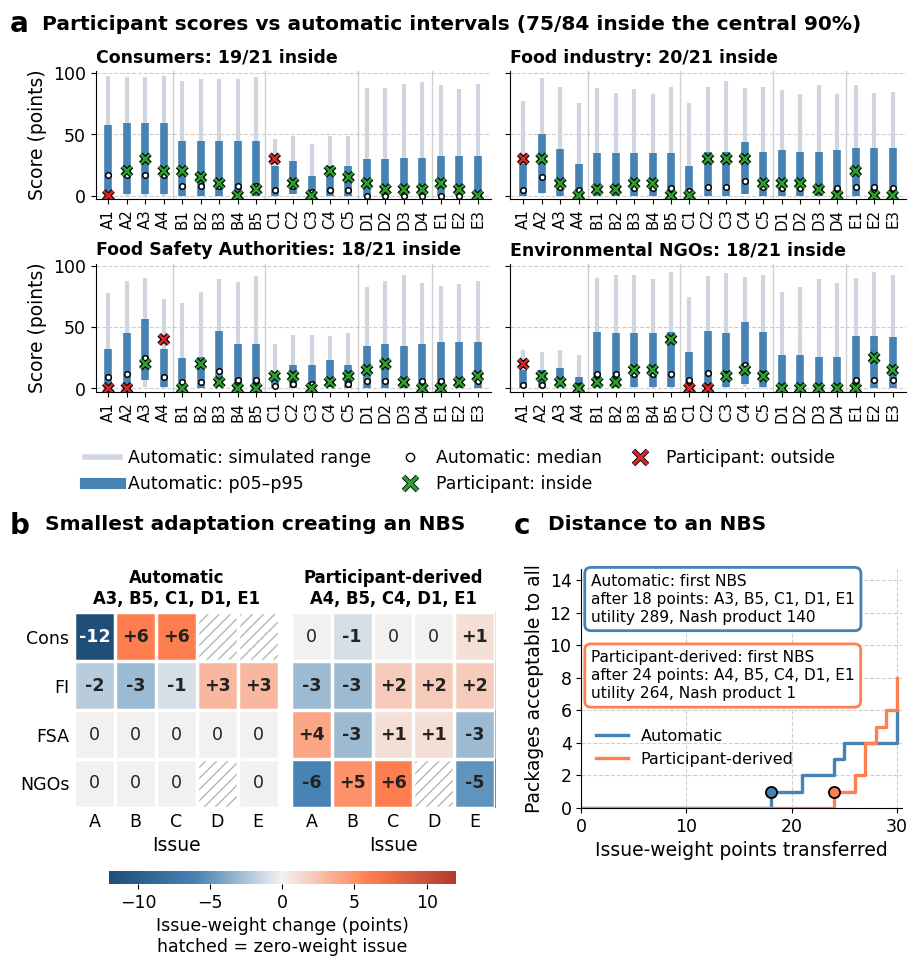

In [6]:
fig = plt.figure(figsize=(9, 9.4))
top, bottom = fig.subfigures(2, 1, height_ratios=[1.12, 1], hspace=0.04)

# ---- (a) participant scores vs automatic intervals
axes = top.subplots(2, 2, sharey=True, gridspec_kw={'hspace': 0.5, 'wspace': 0.05})
outline = [pe.Stroke(linewidth=3.6, foreground='black'), pe.Normal()]
ymax = max(45, float(coverage[['automatic_maximum', 'participant_score']].to_numpy().max()) + 4)
for ax, name in zip(axes.flat, list(dict.fromkeys(coverage.stakeholder))):
    rows = coverage[coverage.stakeholder == name].reset_index(drop=True); x = np.arange(len(rows))
    ax.vlines(x, rows.automatic_minimum, rows.automatic_maximum, color='#cfd6df', linewidth=3, zorder=1)
    ax.vlines(x, rows.automatic_p05, rows.automatic_p95, color=BLUE, linewidth=5.5, zorder=2)
    ax.scatter(x, rows.automatic_median, s=16, color='white', edgecolor='black', linewidth=1.1, zorder=3)
    ins = rows.inside_central_90_interval.to_numpy(bool)
    for mask, color in [(ins, INSIDE), (~ins, OUTSIDE)]:
        ax.scatter(x[mask], rows.participant_score[mask], marker='x', s=45, linewidth=1.9, color=color, zorder=5, path_effects=outline)
    for b in np.flatnonzero(rows.issue.to_numpy()[1:] != rows.issue.to_numpy()[:-1]) + 0.5:
        ax.axvline(b, color='#d0d0d0', linewidth=1, zorder=0)
    ax.set_xticks(x, rows.option, fontsize=FS['small'] * 0.9, rotation=90)
    ax.set_xlim(-0.7, len(rows) - 0.3); ax.set_ylim(-3, ymax)
    ax.set_title(f'{name}: {int(ins.sum())}/{len(rows)} inside', loc='left', fontsize=FS['tick'], fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.6); ax.set_axisbelow(True); clean(ax)
for ax in axes[:, 0]: ax.set_ylabel('Score (points)')
inside_n, total_n = int(coverage.inside_central_90_interval.sum()), len(coverage)
top.legend(handles=[Line2D([0], [0], color='#cfd6df', lw=4, label='Automatic: simulated range'),
                    Line2D([0], [0], color=BLUE, lw=8, label='Automatic: p05–p95'),
                    Line2D([0], [0], marker='o', ls='', mfc='white', mec='black', label='Automatic: median'),
                    Line2D([0], [0], marker='x', ls='', color=INSIDE, ms=10, mew=2.4, path_effects=outline, label='Participant: inside'),
                    Line2D([0], [0], marker='x', ls='', color=OUTSIDE, ms=10, mew=2.4, path_effects=outline, label='Participant: outside')],
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04), columnspacing=1.2, handletextpad=0.5)
top.subplots_adjust(left=0.095, right=0.995, top=0.86, bottom=0.2)
top.text(0.035, 0.975, f'Participant scores vs automatic intervals ({inside_n}/{total_n} inside the central 90%)',
         fontsize=FS['title'], fontweight='bold', va='top')
letter(top, 'a', 0.0, 0.985)

# ---- (b) heatmaps and (c) reachability curve
bl, br = bottom.subfigures(1, 2, width_ratios=[1.25, 1], wspace=0.02)
hm = bl.subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.06})
limit = int(max(d_auto.change.abs().max(), d_part.change.abs().max()))
for ax, d, res, label in [(hm[0], d_auto, res_auto, 'Automatic'), (hm[1], d_part, res_part, 'Participant-derived')]:
    ch = d.pivot(index='stakeholder', columns='issue', values='change').reindex(index=STAKEHOLDERS, columns=ISSUES)
    w0 = d.pivot(index='stakeholder', columns='issue', values='original_weight').reindex(index=STAKEHOLDERS, columns=ISSUES)
    im = ax.imshow(ch.to_numpy(float), cmap=DIVERGING, vmin=-limit, vmax=limit, aspect='auto')
    for i in range(len(STAKEHOLDERS)):
        for j in range(len(ISSUES)):
            if w0.iat[i, j] == 0:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, facecolor='white', edgecolor='#b5b5b5', hatch='///', lw=0)); continue
            v = int(ch.iat[i, j])
            ax.text(j, i, f'{v:+d}' if v else '0', ha='center', va='center', fontsize=FS['ann'],
                    fontweight='bold' if v else 'normal', color='white' if abs(v) > 0.6 * limit else INK)
    ax.set_xticks(range(len(ISSUES)), ISSUES); ax.set_yticks(range(len(STAKEHOLDERS)), [SHORT[s] for s in STAKEHOLDERS])
    ax.set_xticks(np.arange(-.5, len(ISSUES)), minor=True); ax.set_yticks(np.arange(-.5, len(STAKEHOLDERS)), minor=True)
    ax.grid(which='minor', color='white', linewidth=2.5); ax.tick_params(which='both', length=0)
    for s in ax.spines.values(): s.set_visible(False)
    sm = res['smallest_practical_genuine_nbs_profile']
    ax.set_title(f"{label}\n{sm['equilibrium']['benchmark_package']}", fontsize=FS['tick'] * 0.95, fontweight='bold')
    ax.set_xlabel('Issue')
bl.subplots_adjust(left=0.13, right=0.98, top=0.76, bottom=0.31)
cax = bl.add_axes([0.2, 0.135, 0.7, 0.03])
cb = bl.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label('Issue-weight change (points)\nhatched = zero-weight issue', fontsize=FS['tick']); cb.outline.set_visible(False)
letter(bl, 'b', 0.0, 0.99)
bl.text(0.07, 0.985, 'Smallest adaptation creating an NBS', fontsize=FS['title'], fontweight='bold', va='top')

ax = br.subplots()
budgets = np.arange(0, CAP + 1)
for label, color, ytxt in [('Automatic', BLUE, 0.98), ('Participant-derived', CORAL, 0.66)]:
    totals = transfer[label].total.to_numpy()
    ax.step(budgets, [(totals <= b).sum() for b in budgets], where='post', color=color, lw=2.4, label=label)
    f = first[label]
    ax.plot(f['points'], 1, 'o', ms=8, color=color, mec='black', mew=1.3, zorder=5)
    ax.text(0.03, ytxt, f"{label}: first NBS\nafter {f['points']} points: {f['package']}\nutility {f['total']}, Nash product {f['nash']}",
            transform=ax.transAxes, fontsize=FS['small'] * 0.92, va='top', linespacing=1.25,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, linewidth=2))
ax.set_xlim(0, CAP + 0.5); ax.set_ylim(0, max(11.5, ax.get_ylim()[1] * 1.75))
ax.set_xlabel('Issue-weight points transferred'); ax.set_ylabel('Packages acceptable to all')
ax.grid(linestyle='--', alpha=0.6); ax.set_axisbelow(True); clean(ax)
from matplotlib.ticker import MaxNLocator; ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(0.0, 0.25), fontsize=FS['leg'] * 0.92)
br.subplots_adjust(left=0.17, right=0.98, top=0.86, bottom=0.31)
letter(br, 'c', 0.0, 0.99)
br.text(0.085, 0.985, 'Distance to an NBS', fontsize=FS['title'], fontweight='bold', va='top')

for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'Figure1_automatic_vs_participant_derived.{ext}', dpi=300, bbox_inches='tight', pad_inches=0.05)
print('Saved', OUT / 'Figure1_automatic_vs_participant_derived.png')
plt.show()

# Section 2 — Figure 2: negotiation outcomes and perception of public statements

Layout: **row 1** — (a) final deals vs the NBS, (b) equilibrium landscape (where the runs ended); **row 2** — (c) what the opponent models received, (d) learning over the negotiation, (e) overall information at start vs final vote, (f) NBS rank at start vs final vote.

### 2.1 Analysis code

In [7]:
import json, shutil
from pathlib import Path
# Structural part (issues, relevant issues, ordinal relations, source hashes) of the GPT-5.5 priors used in the runs
EMBEDDED_PRIORS = json.loads('{"schema": "semantic_ordinal_prior_v1", "model": "gpt-5.5", "created_utc": "2026-10-05T00:05:27.563037+00:00", "private_files_used": false, "note": "Structural fields of the GPT-5.5 public_priors_Campylobacter.json used in the runs (texts omitted).", "stakeholders": {"Consumers": {"issues": {"A": {"options": {"A1": {}, "A2": {}, "A3": {}, "A4": {}}}, "B": {"options": {"B1": {}, "B2": {}, "B3": {}, "B4": {}, "B5": {}}}, "C": {"options": {"C1": {}, "C2": {}, "C3": {}, "C4": {}, "C5": {}}}, "D": {"options": {"D1": {}, "D2": {}, "D3": {}, "D4": {}}}, "E": {"options": {"E1": {}, "E2": {}, "E3": {}}}}, "relevant_issues": ["A", "B", "C"], "issue_relations": [{"more_important": "A", "less_important": "C"}], "option_relations": [{"preferred": "C2", "less_preferred": "C3"}], "source_file": "preliminary_discussion.json", "source_sha256": "779546b6d8a3f6aa75d5757913844f08ed6cb1d2be7383a9a6c88fbd2dd09b07", "total_points": 100.0, "acceptance_threshold": 65.0}, "Food industry": {"issues": {"A": {"options": {"A1": {}, "A2": {}, "A3": {}, "A4": {}}}, "B": {"options": {"B1": {}, "B2": {}, "B3": {}, "B4": {}, "B5": {}}}, "C": {"options": {"C1": {}, "C2": {}, "C3": {}, "C4": {}, "C5": {}}}, "D": {"options": {"D1": {}, "D2": {}, "D3": {}, "D4": {}}}, "E": {"options": {"E1": {}, "E2": {}, "E3": {}}}}, "relevant_issues": ["A", "B", "C", "D", "E"], "issue_relations": [], "option_relations": [{"preferred": "A2", "less_preferred": "A1"}, {"preferred": "A2", "less_preferred": "A4"}, {"preferred": "C4", "less_preferred": "C1"}], "source_file": "preliminary_discussion.json", "source_sha256": "5e9e9ff40b61852d3f91b5f1cc79d6c22b7fa3062fe8db092e3e40807fb03914", "total_points": 100.0, "acceptance_threshold": 65.0}, "Food Safety Authorities": {"issues": {"A": {"options": {"A1": {}, "A2": {}, "A3": {}, "A4": {}}}, "B": {"options": {"B1": {}, "B2": {}, "B3": {}, "B4": {}, "B5": {}}}, "C": {"options": {"C1": {}, "C2": {}, "C3": {}, "C4": {}, "C5": {}}}, "D": {"options": {"D1": {}, "D2": {}, "D3": {}, "D4": {}}}, "E": {"options": {"E1": {}, "E2": {}, "E3": {}}}}, "relevant_issues": ["A", "B", "C", "D", "E"], "issue_relations": [{"more_important": "A", "less_important": "C"}], "option_relations": [{"preferred": "A3", "less_preferred": "A1"}, {"preferred": "A3", "less_preferred": "A4"}, {"preferred": "B3", "less_preferred": "B1"}, {"preferred": "B3", "less_preferred": "B2"}, {"preferred": "C4", "less_preferred": "C1"}], "source_file": "preliminary_discussion.json", "source_sha256": "38f67f29d16bf7966e65c774a5ce9b8fdd619140f67e1cfe19036f75789021c8", "total_points": 100.0, "acceptance_threshold": 65.0}, "Environmental NGOs": {"issues": {"A": {"options": {"A1": {}, "A2": {}, "A3": {}, "A4": {}}}, "B": {"options": {"B1": {}, "B2": {}, "B3": {}, "B4": {}, "B5": {}}}, "C": {"options": {"C1": {}, "C2": {}, "C3": {}, "C4": {}, "C5": {}}}, "D": {"options": {"D1": {}, "D2": {}, "D3": {}, "D4": {}}}, "E": {"options": {"E1": {}, "E2": {}, "E3": {}}}}, "relevant_issues": ["A", "B", "C", "E"], "issue_relations": [{"more_important": "B", "less_important": "A"}, {"more_important": "C", "less_important": "A"}], "option_relations": [{"preferred": "A3", "less_preferred": "A4"}, {"preferred": "C4", "less_preferred": "C1"}], "source_file": "preliminary_discussion.json", "source_sha256": "5f1d3e6080e7b2c2dc9bb50d4279633f0c01508142db4f786500817ff2f51cfd", "total_points": 100.0, "acceptance_threshold": 65.0}}}')

In [8]:
"""Aggregate argument-perception statistics across negotiation run folders.

Reads, for every run folder in OUTPUT_DIR:
  answers*.json                    public messages (speaker, text)
  semantic_evidence_cache.json     what each message was turned into
  bayesian_inference_calls.jsonl   each opponent-model state the agents saw
  run_summary.json                 outcome (missing = unfinished run)
The true adapted profile is used only for retrospective evaluation.
"""
import glob, hashlib, json, re
from pathlib import Path
import numpy as np
import pandas as pd

CATALOG = {'A': ['A1', 'A2', 'A3', 'A4'], 'B': ['B1', 'B2', 'B3', 'B4', 'B5'], 'C': ['C1', 'C2', 'C3', 'C4', 'C5'],
           'D': ['D1', 'D2', 'D3', 'D4'], 'E': ['E1', 'E2', 'E3']}
ISSUES = list(CATALOG)
THRESHOLD = 65
# Wording that states a position (support, objection, need, priority) without the extractor recording it.
POSITION_RE = re.compile(r"\b(cannot|can't|can not|unable|essential|need|needs|must|accept|accepting|support|prefer|"
                         r"priorit\w*|concern\w*|insist|require\w*|non-negotiable|unacceptable|reject\w*|oppose)\b", re.I)
OPT_RE = re.compile(r"\b([A-E][1-5])\b")
DEAL_RE = re.compile(r"<DEAL>(.*?)</DEAL>", re.S)
Q_RE = re.compile(r'<QUESTION\s+target="([^"]+)"(?:\s+option="([^"]*)")?\s*>(.*?)</QUESTION>', re.S)


def cache_key(model, speaker, message):
    return hashlib.sha256(json.dumps([model, speaker, message, CATALOG], sort_keys=True).encode()).hexdigest()


def score(table, deal):
    return sum(table[o[0]][o] for o in deal)


def _read_jsonl(path):
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            # A record cut off by a concurrent write can be glued to the next one on the same line:
            # keep the complete record that follows; drop the fragment (and a truncated last line).
            cut = line.find('{"status"', 1)
            while cut > 0:
                try:
                    rows.append(json.loads(line[cut:]))
                    break
                except json.JSONDecodeError:
                    cut = line.find('{"status"', cut + 1)
    return rows


def extract_archives(zip_paths, dest):
    """Unzip one or several archives into the same folder.

    Google Drive splits a large folder download into several zips (...-1-001.zip, ...-1-002.zip);
    upload all parts and they are merged here.
    """
    import zipfile
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    for zp in zip_paths:
        with zipfile.ZipFile(zp) as z:
            for member in z.namelist():  # refuse paths that would escape the destination
                target = (dest / member).resolve()
                if not str(target).startswith(str(dest.resolve())):
                    raise ValueError(f'Unsafe path in {zp}: {member}')
            z.extractall(dest)
    return dest


def find_run_dirs(root):
    """Every folder (at any depth) that holds a negotiation run; crashed attempts are skipped."""
    found = {}
    for log in Path(root).rglob('bayesian_inference_calls.jsonl'):
        d = log.parent
        if '_aborted_attempts' in d.parts or '__MACOSX' in d.parts or not list(d.glob('answers*.json')):
            continue
        rank = ((d / 'run_summary.json').exists(), len(list(d.iterdir())))
        if d.name not in found or rank > found[d.name][0]:  # same run in two archives: keep the most complete copy
            found[d.name] = (rank, d)
    return [d for _, d in sorted(found.values(), key=lambda x: x[1].name)]


MODERATOR_NAMES = {'consumers': 'Consumers', 'food_industry': 'Food industry',
                   'food_safety_authorities': 'Food Safety Authorities', 'environmental_ngos': 'Environmental NGOs'}


def _run_seed(d, summary):
    if summary and 'random_seed' in summary:
        return int(summary['random_seed'])
    m = re.search(r'_seed_(\d+)', d.name)
    return int(m.group(1)) if m else 0


def _vote_turns(d, rounds):
    """Turn at which each voting session took place (= number of public statements its prompt had seen)."""
    norm = lambda x: re.sub(r'\s+', ' ', str(x)).strip()
    texts = [norm(t) for _, t in rounds]
    out = {}
    for f in sorted(d.glob('full_conversation*.json'))[-1:]:
        for k, v in json.loads(f.read_text()).get('voting_sessions', {}).items():
            prompt = norm(v.get('deal_suggestion', {}).get('prompt', '')) if isinstance(v.get('deal_suggestion'), dict) else ''
            hist = prompt.split('<HISTORY>')[1].split('</HISTORY>')[0] if '<HISTORY>' in prompt else ''
            hits = [i for i, t in enumerate(texts) if t[:80] and t[:80] in hist]
            out[str(k)] = max(hits) + 1 if hits else len(texts)
    return out


def load_runs(output_dir, model='gpt-5.5'):
    runs = []
    for d in find_run_dirs(output_dir):
        ans_files = sorted(d.glob('answers*.json'))
        summary = json.loads((d / 'run_summary.json').read_text()) if (d / 'run_summary.json').exists() else None
        m = re.search(r'(consumers|food_industry|food_safety_authorities|environmental_ngos)_moderator_run_(\d+)', d.name)
        runs.append(dict(
            run=d.name, moderator=MODERATOR_NAMES.get(m.group(1), m.group(1)) if m else '', rep=int(m.group(2)) if m else 0,
            outcome='unfinished' if summary is None else summary.get('outcome', 'agreement' if summary.get('proposal_passes') else 'no_agreement'),
            final_deal=None if summary is None else summary.get('final_deal'), summary=summary,
            messages=json.loads(ans_files[-1].read_text())['rounds'],
            cache=json.loads((d / 'semantic_evidence_cache.json').read_text()) if (d / 'semantic_evidence_cache.json').exists() else {},
            calls=_read_jsonl(d / 'bayesian_inference_calls.jsonl'),
            seed=_run_seed(d, summary), vote_turns=_vote_turns(d, json.loads(ans_files[-1].read_text())['rounds']),
            model=model))
    return runs


def check_profile(runs, true):
    """The evaluation profile must reproduce the true scores each finished run recorded for its final deal."""
    bad = []
    for r in runs:
        s = r['summary']
        if not s or not s.get('final_deal'):
            continue
        deal = [x.strip() for x in s['final_deal'].split(',')]
        for row in s.get('stakeholders', []):
            if row['stakeholder'] in true and abs(score(true[row['stakeholder']], deal) - row['true_score_evaluation_only']) > 1e-6:
                bad.append((r['run'], row['stakeholder']))
    return bad


def outcome_label(run, nbs):
    if run['outcome'] == 'unfinished':
        return 'unfinished'
    if run['outcome'] != 'agreement':
        return 'no agreement'
    deal = [x.strip() for x in run['final_deal'].split(',')]
    return 'NBS' if deal == nbs else 'other agreement'


def statement_table(runs, true, nbs):
    """One row per public message: what the evidence extractor made of it."""
    rows, ev_rows, q_rows = [], [], []
    for run in runs:
        msgs = run['messages']
        for i, (speaker, text) in enumerate(msgs):
            text = str(text)
            ex = run['cache'].get(cache_key(run['model'], speaker, text))
            comps = [c for c in (ex or {}).get('comparisons', [])]
            stances = [s for s in (ex or {}).get('deal_stances', [])]
            used_c = [c for c in comps if not c.get('conditional')]
            used_s = [s for s in stances if s.get('stance') != 'conditional']
            dropped = [c for c in comps if c.get('conditional')] + [s for s in stances if s.get('stance') == 'conditional']
            unresolved = (ex or {}).get('unresolved_conditions', [])
            plain = Q_RE.sub(' ', DEAL_RE.sub(' ', text))
            position_words = bool(POSITION_RE.search(plain))
            if ex is None:
                cat = 'not processed'
            elif used_c or used_s:
                cat = 'used as evidence'
            elif dropped or unresolved:
                cat = 'conditional (dropped)'
            elif position_words:
                cat = 'position not captured'
            else:
                cat = 'proposal only'
            rows.append(dict(run=run['run'], moderator=run['moderator'], outcome=outcome_label(run, nbs), turn=i, speaker=speaker, category=cat,
                             n_used=len(used_c) + len(used_s), n_dropped=len(dropped) + len(unresolved),
                             has_question=bool(Q_RE.search(text)), text=text))
            T = true[speaker]
            for c in used_c:
                ok = T[c['preferred'][0]][c['preferred']] > T[c['preferred'][0]][c['less_preferred']]
                tie = T[c['preferred'][0]][c['preferred']] == T[c['preferred'][0]][c['less_preferred']]
                ev_rows.append(dict(run=run['run'], turn=i, speaker=speaker, kind='preference', item=f"{c['preferred']}>{c['less_preferred']}",
                                    truthful=bool(ok), tie=bool(tie)))
            for s in used_s:
                sc = score(T, s['deal'])
                ok = sc >= THRESHOLD if s['stance'] == 'accept' else sc < THRESHOLD
                ev_rows.append(dict(run=run['run'], turn=i, speaker=speaker, kind=s['stance'], item=', '.join(s['deal']),
                                    truthful=bool(ok), tie=False, true_score=sc))
            # questions asked in this message and what the target did next
            for target, option, qtext in Q_RE.findall(text):
                target = next((n for n in true if n.casefold() == target.strip().casefold()), target.strip())
                asked = set(OPT_RE.findall(qtext)) | ({option} if option else set())
                nxt = next((j for j in range(i + 1, len(msgs)) if msgs[j][0] == target), None)
                if nxt is None:
                    q_rows.append(dict(run=run['run'], turn=i, asker=speaker, target=target, options='/'.join(sorted(asked)),
                                       status='no later turn'))
                    continue
                reply = str(msgs[nxt][1])
                rex = run['cache'].get(cache_key(run['model'], target, reply)) or {}
                mentioned = bool(asked & set(OPT_RE.findall(Q_RE.sub(' ', reply))))
                ev_opts = set()
                for c in rex.get('comparisons', []):
                    if not c.get('conditional'):
                        ev_opts |= {c['preferred'], c['less_preferred']}
                for s in rex.get('deal_stances', []):
                    if s.get('stance') != 'conditional':
                        ev_opts |= set(s['deal'])
                comp_opts = set()
                for c in rex.get('comparisons', []):
                    if not c.get('conditional'):
                        comp_opts |= {c['preferred'], c['less_preferred']}
                if asked & comp_opts or (asked & ev_opts and not option):
                    status = 'answered → evidence'
                elif mentioned:
                    status = 'addressed, not extracted'
                else:
                    status = 'not addressed'
                q_rows.append(dict(run=run['run'], turn=i, asker=speaker, target=target, options='/'.join(sorted(asked)), status=status))
    return pd.DataFrame(rows), pd.DataFrame(ev_rows), pd.DataFrame(q_rows)


def obs_key(obs):
    return tuple(sorted((o['type'], o.get('preferred', ''), o.get('less_preferred', ''), tuple(o.get('deal', [])), o.get('stance', ''))
                        for o in obs))


def belief_metrics(est, T, nbs):
    pairs = correct = 0
    for issue in ISSUES:
        for a in CATALOG[issue]:
            for b in CATALOG[issue]:
                if a < b and T[issue][a] != T[issue][b]:
                    pairs += 1
                    correct += (est[issue][a] - est[issue][b]) * (T[issue][a] - T[issue][b]) > 0
    est_nbs = sum(est[o[0]][o] for o in nbs)
    return dict(rank_accuracy=correct / pairs, nbs_est=est_nbs, nbs_true=score(T, nbs), nbs_abs_error=abs(est_nbs - score(T, nbs)))


def state_table(runs, true, nbs):
    """Unique opponent-model states per run and opponent (posterior is deterministic given the evidence)."""
    rows, seen = [], set()
    for run in runs:
        for c in run['calls']:
            if c.get('status') not in ('posterior_estimated', 'evidence_conflict_prior_returned'):
                continue
            opp, obs = c['opponent'], c.get('observations_used', [])
            key = (run['run'], opp, obs_key(obs))
            if key in seen:
                continue
            seen.add(key)
            rows.append(dict(run=run['run'], moderator=run['moderator'], outcome=outcome_label(run, nbs), opponent=opp, n_obs=len(obs),
                             last_round=max([o['round'] for o in obs], default=-1), obs_key=obs_key(obs), obs=obs,
                             surviving=c['surviving_fraction'], conflict=c['status'] != 'posterior_estimated',
                             **belief_metrics(c['estimated_utility_function'], true[opp], nbs)))
    return pd.DataFrame(rows)


def transitions(states):
    """Effect of each newly recognised statement: compare the state before and after it was added."""
    rows = []
    for (run, opp), g in states.groupby(['run', 'opponent']):
        g = g.sort_values('n_obs')
        prev = None
        for r in g.itertuples():
            if prev is not None and set(prev.obs_key) < set(r.obs_key):
                new = [o for o in r.obs if obs_key([o])[0] not in set(prev.obs_key)]
                kinds = {('preference' if o['type'] == 'comparison' else o['stance']) for o in new}
                rows.append(dict(run=run, outcome=r.outcome, opponent=opp, kind=kinds.pop() if len(kinds) == 1 else 'mixed',
                                 n_new=len(new), ruled_out=100 * (1 - r.surviving / prev.surviving),
                                 d_rank=100 * (r.rank_accuracy - prev.rank_accuracy),
                                 d_nbs_error=r.nbs_abs_error - prev.nbs_abs_error))
            prev = r
    return pd.DataFrame(rows)


def p_accept_shifts(runs, true, nbs):
    """Same candidate deal, same opponent, different evidence: did P(accept) move toward the truth?"""
    rows = []
    for run in runs:
        best = {}
        for c in run['calls']:
            cd = c.get('candidate_deal_distribution')
            if not cd:
                continue
            k = (c['opponent'], tuple(cd['deal']))
            best.setdefault(k, {})[obs_key(c.get('observations_used', []))] = (len(c.get('observations_used', [])), cd['probability_meeting_threshold'])
        for (opp, deal), states in best.items():
            if len(states) < 2:
                continue
            ordered = sorted(states.values())
            (n0, p0), (n1, p1) = ordered[0], ordered[-1]
            truly = score(true[opp], deal) >= THRESHOLD
            rows.append(dict(run=run['run'], moderator=run['moderator'], outcome=outcome_label(run, nbs), opponent=opp, deal=', '.join(deal),
                             truly_acceptable=truly, p_before=p0, p_after=p1,
                             toward_truth=(p1 - p0) * (1 if truly else -1)))
    return pd.DataFrame(rows)


def belief_by_turn(runs, states, true, nbs):
    """Belief quality each listener could have at every turn (latest state built only from earlier statements)."""
    rows = []
    for run in runs:
        n = len(run['messages'])
        for opp in true:
            g = states[(states.run == run['run']) & (states.opponent == opp)]
            for t in range(n + 1):
                ok = g[g.last_round < t]
                if ok.empty:
                    continue
                r = ok.sort_values('n_obs').iloc[-1]
                rows.append(dict(run=run['run'], outcome=outcome_label(run, nbs), opponent=opp, turn=t,
                                 rank_accuracy=r.rank_accuracy, nbs_abs_error=r.nbs_abs_error, surviving=r.surviving, n_obs=r.n_obs))
    return pd.DataFrame(rows)


In [9]:
"""Decision-relevant knowledge of the opponent models, rebuilt exactly from the public priors.

For every run, turn t and party s, the posterior is the public prior of s conditioned on the
unconditional comparisons and accept/reject stances s made in public statements before turn t
(the same rule and random seed as the negotiation tool, so it reproduces the logged calls).
From the posterior samples we compute, for any package, P(party scores >= 65).
"""
import hashlib, itertools, json
import numpy as np
import pandas as pd

# ---- sampler copied from semantic_bayesian_inference.py (unchanged logic) ----

def _stable_seed(*parts):
    blob = json.dumps(parts, sort_keys=True, ensure_ascii=False).encode('utf-8')
    return int.from_bytes(hashlib.sha256(blob).digest()[:8], 'big')


def _valid_active_sets(issues, relevant, edges):
    valid = []
    for bits in itertools.product((False, True), repeat=len(issues)):
        active = {issue for issue, bit in zip(issues, bits) if bit}
        if not active or not relevant.issubset(active):
            continue
        if any(low in active and high not in active for high, low in edges):
            continue
        valid.append(tuple(issue for issue in issues if issue in active))
    if not valid:
        raise ValueError('Public prior constraints permit no active-issue configuration')
    return valid


def _valid_permutations(items, edges):
    result = []
    for permutation in itertools.permutations(items):
        position = {item: idx for idx, item in enumerate(permutation)}
        if all(high not in position or low not in position or position[high] < position[low] for high, low in edges):
            result.append(permutation)
    if not result:
        raise ValueError(f'Cyclic or impossible ordinal constraints for {items}')
    return result


def sample_public_prior(stakeholder_prior, n_samples, seed):
    issues = sorted(stakeholder_prior['issues'])
    relevant = set(stakeholder_prior.get('relevant_issues', []))
    issue_edges = [(r['more_important'], r['less_important']) for r in stakeholder_prior.get('issue_relations', [])]
    valid_sets = _valid_active_sets(issues, relevant, issue_edges)
    rng = np.random.default_rng(seed)
    selected_sets = [valid_sets[i] for i in rng.integers(0, len(valid_sets), size=n_samples)]
    total = float(stakeholder_prior['total_points'])
    issue_weights = {issue: np.zeros(n_samples, dtype=float) for issue in issues}
    for active in sorted(set(selected_sets)):
        indices = np.array([i for i, value in enumerate(selected_sets) if value == active], dtype=int)
        k = len(active)
        raw = rng.dirichlet(np.ones(k), size=len(indices))
        permutations = _valid_permutations(active, issue_edges)
        chosen = rng.integers(0, len(permutations), size=len(indices))
        sorted_values = np.sort(raw, axis=1)[:, ::-1] * total
        for row_idx, sample_idx in enumerate(indices):
            for rank, issue in enumerate(permutations[chosen[row_idx]]):
                issue_weights[issue][sample_idx] = sorted_values[row_idx, rank]
    scores = {}
    for issue in issues:
        options = tuple(sorted(stakeholder_prior['issues'][issue]['options']))
        option_edges = [(r['preferred'], r['less_preferred']) for r in stakeholder_prior.get('option_relations', [])
                        if r['preferred'].startswith(issue) and r['less_preferred'].startswith(issue)]
        permutations = _valid_permutations(options, option_edges)
        chosen = rng.integers(0, len(permutations), size=n_samples)
        raw = np.sort(rng.random((n_samples, len(options))), axis=1)[:, ::-1]
        raw[:, 0] = 1.0
        scores[issue] = {option: np.zeros(n_samples, dtype=float) for option in options}
        for sample_idx in range(n_samples):
            for rank, option in enumerate(permutations[chosen[sample_idx]]):
                scores[issue][option][sample_idx] = issue_weights[issue][sample_idx] * raw[sample_idx, rank]
    return {'issues': issues, 'issue_weights': issue_weights, 'scores': scores, 'n_samples': n_samples}


# ---- evidence and posteriors per turn ----

def observations_before(run, speaker, turn, cache_key, exclude_deals=()):
    """Same rule as collect_live_evidence, restricted to the speaker's statements before `turn`."""
    obs, seen = [], set()
    exclude = {tuple(d) for d in exclude_deals}
    for i, (sp, text) in enumerate(run['messages'][:turn]):
        if sp != speaker:
            continue
        ex = run['cache'].get(cache_key(run['model'], sp, str(text))) or {}
        for c in ex.get('comparisons', []):
            if c.get('conditional'):
                continue
            key = ('comparison', c['preferred'], c['less_preferred'])
            if key not in seen:
                seen.add(key); obs.append({'type': 'comparison', **c})
        for s in ex.get('deal_stances', []):
            if s.get('stance') == 'conditional' or tuple(s['deal']) in exclude:
                continue
            key = ('deal_stance', tuple(s['deal']), s['stance'])
            if key not in seen:
                seen.add(key); obs.append({'type': 'deal_stance', **s})
    return obs


class PartyModel:
    """Prior samples for one party in one run; P(accept) for all packages under any evidence set."""

    def __init__(self, prior, seed, name, catalog, n_samples=12000, threshold=65.0):
        self.s = sample_public_prior(prior, n_samples, _stable_seed(seed, name, prior['source_sha256']))
        self.issues = list(catalog)
        self.catalog = catalog
        self.threshold = threshold
        self.mat = {i: np.stack([self.s['scores'][i][o] for o in catalog[i]], axis=1).astype(np.float32) for i in self.issues}
        self._memo = {}

    def mask(self, obs):
        m = np.ones(self.s['n_samples'], dtype=bool)
        for o in obs:
            if o['type'] == 'comparison':
                i = o['preferred'][0]
                m &= self.s['scores'][i][o['preferred']] > self.s['scores'][i][o['less_preferred']]
            else:
                v = sum(self.s['scores'][i][opt] for i, opt in zip(self.issues, o['deal']))
                m &= v >= self.threshold if o['stance'] == 'accept' else v < self.threshold
        if not m.any():  # contradictory evidence: the tool falls back to the prior
            m[:] = True
        return m

    def p_accept_all(self, obs):
        """P(score >= threshold) for every package, as an array over the full package grid."""
        key = tuple(sorted(json.dumps(o, sort_keys=True) for o in obs))
        if key not in self._memo:
            m = self.mask(obs)
            tot = None
            for k, i in enumerate(self.issues):
                a = self.mat[i][m]
                shape = [a.shape[0]] + [1] * len(self.issues)
                shape[k + 1] = a.shape[1]
                a = a.reshape(shape)
                tot = a if tot is None else tot + a
            self._memo[key] = ((tot >= self.threshold).mean(axis=0)).reshape(-1), float(m.mean())
        return self._memo[key]


def package_index(catalog):
    packages = list(itertools.product(*catalog.values()))
    return packages, {p: k for k, p in enumerate(packages)}


def first_deal(text):
    import re
    m = re.search(r'<DEAL>(.*?)</DEAL>', str(text), re.S)
    if not m:
        return None
    parts = [x.strip().upper() for x in m.group(1).split(',') if x.strip()]
    by_issue = {p[0]: p for p in parts}
    return by_issue


def useful_knowledge(runs, priors, true, nbs, catalog, cache_key, outcome_label, exclude_nbs_stances=True,
                     n_samples=12000, threshold=65.0, progress=print):
    """Per run and turn: NBS rank, P(each party accepts the NBS), stance prediction for the proposal on the table."""
    packages, idx = package_index(catalog)
    issues = list(catalog)
    nbs_t = tuple(nbs)
    true_acc = {s: np.array([sum(true[s][o[0]][o] for o in p) >= threshold for p in packages]) for s in true}
    parties = list(true)
    turn_rows, proposal_rows, vote_rows = [], [], []
    for r in runs:
        seed = r['seed']
        models = {s: PartyModel(priors[s], seed, s, catalog, n_samples, threshold) for s in parties}
        outcome = outcome_label(r, nbs)
        n = len(r['messages'])
        nbs_first = next((i for i, (_, t) in enumerate(r['messages'])
                          if (d := first_deal(t)) and tuple(d.get(i_, '') for i_ in issues) == nbs_t), None)
        for t in range(n + 1):
            excl = [nbs] if exclude_nbs_stances else []
            P = {s: models[s].p_accept_all(observations_before(r, s, t, cache_key, excl))[0] for s in parties}
            joint = np.prod(np.stack([P[s] for s in parties]), axis=0)
            k = idx[nbs_t]
            rank = int((joint > joint[k]).sum()) + 1
            turn_rows.append(dict(run=r['run'], moderator=r['moderator'], outcome=outcome, turn=t, nbs_rank=rank,
                                  p_nbs_mean=float(np.mean([P[s][k] for s in parties])), p_nbs_all=float(joint[k]),
                                  nbs_first_proposed=nbs_first, **{f'p_nbs_{s}': float(P[s][k]) for s in parties}))
            # proposal on the table at turn t, judged with models built from statements before t (all evidence)
            if t < n:
                d = first_deal(r['messages'][t][1])
                if d and all(i in d for i in issues):
                    pkg = tuple(d[i] for i in issues)
                    if pkg in idx:
                        Pf = {s: models[s].p_accept_all(observations_before(r, s, t, cache_key))[0][idx[pkg]] for s in parties}
                        for s in parties:
                            truly = bool(true_acc[s][idx[pkg]])
                            proposal_rows.append(dict(run=r['run'], moderator=r['moderator'], outcome=outcome, turn=t,
                                                      proposer=r['messages'][t][0], party=s, deal=', '.join(pkg),
                                                      p_accept=float(Pf[s]), truly_accepts=truly,
                                                      correct=bool((Pf[s] >= 0.5) == truly)))
        # votes: was the party that sank (or would sink) the proposal foreseen?
        for v in (r.get('summary') or {}).get('voting_history', []):
            pkg = tuple(x.strip() for x in v['deal'].split(','))
            if pkg not in idx:
                continue
            tv = r.get('vote_turns', {}).get(str(v['session']), n)
            P = {s: models[s].p_accept_all(observations_before(r, s, tv, cache_key))[0][idx[pkg]] for s in parties}
            for s in parties:
                truly = bool(true_acc[s][idx[pkg]])
                vote_rows.append(dict(run=r['run'], moderator=r['moderator'], outcome=outcome, session=str(v['session']),
                                      vote_turn=tv, deal=v['deal'], party=s, p_accept=float(P[s]), truly_accepts=truly,
                                      predicted_accepts=bool(P[s] >= 0.5), correct=bool((P[s] >= 0.5) == truly),
                                      passed=v.get('proposal_passes')))
        progress(f"  {r['run']}: done")
    return pd.DataFrame(turn_rows), pd.DataFrame(proposal_rows), pd.DataFrame(vote_rows)


def information_location(runs, priors, nbs, catalog, cache_key, outcome_label, tu, include_last_statement=False,
                         exclude_nbs_stances=True, n_samples=12000, n_packages=1200):
    """Per run, at the final vote: how much information the four models gained (bits) and where it lies.

    bits      = -log2(share of the prior still possible), summed over the four party models
    distance  = mean number of issues on which a package the parties publicly accepted or rejected differs from the NBS
                (stances on the NBS itself are excluded when exclude_nbs_stances=True, as in the models)
    rank_gain = gain in packages ranked below the NBS (percentage points), start -> final vote
    """
    rows, items = [], []
    for r in runs:
        end = max(r.get('vote_turns', {}).values() or [len(r['messages'])]) - (0 if include_last_statement else 1)
        excl = [nbs] if exclude_nbs_stances else []
        bits = {}
        for s in priors:
            obs = observations_before(r, s, end, cache_key, excl)
            pm = PartyModel(priors[s], r['seed'], s, catalog, n_samples)
            bits[s] = float(-np.log2(pm.mask(obs).mean()))
            for o in obs:
                if o['type'] == 'deal_stance':
                    items.append(dict(run=r['run'], party=s, stance=o['stance'],
                                      distance=sum(a != b for a, b in zip(o['deal'], nbs))))
        g = tu[tu.run == r['run']].sort_values('turn')
        g = g[g.turn <= end]
        gain = 100 * (g.nbs_rank.iloc[0] - g.nbs_rank.iloc[-1]) / n_packages
        d = [i['distance'] for i in items if i['run'] == r['run']]
        rows.append(dict(run=r['run'], moderator=r['moderator'], outcome=outcome_label(r, nbs), end_turn=end,
                         bits=sum(bits.values()), **{f'bits_{s}': v for s, v in bits.items()},
                         n_stances=len(d), distance=float(np.mean(d)) if d else np.nan, rank_gain=gain,
                         gain_per_bit=gain / sum(bits.values()) if sum(bits.values()) > 0 else np.nan))
    return pd.DataFrame(rows), pd.DataFrame(items)


def compare_nbs_vs_rest(info, metrics=('bits', 'distance', 'rank_gain', 'gain_per_bit')):
    from scipy import stats
    out = []
    a = info[info.outcome == 'NBS']; b = info[info.outcome != 'NBS']
    for m in metrics:
        x, y = a[m].dropna(), b[m].dropna()
        out.append(dict(metric=m, nbs_mean=x.mean(), nbs_sem=x.sem(), n_nbs=len(x), rest_mean=y.mean(), rest_sem=y.sem(),
                        n_rest=len(y), p_welch=stats.ttest_ind(x, y, equal_var=False).pvalue if len(x) > 1 and len(y) > 1 else np.nan,
                        p_mannwhitney=stats.mannwhitneyu(x, y).pvalue if len(x) and len(y) else np.nan))
    return pd.DataFrame(out)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 15, 'axes.titlesize': 17, 'axes.titleweight': 'bold',
                     'axes.labelsize': 15, 'xtick.labelsize': 13.5, 'ytick.labelsize': 13.5, 'legend.fontsize': 13.5,
                     'axes.spines.top': False, 'axes.spines.right': False, 'savefig.dpi': 300})
FS = dict(letter=24, title=17, tick=13.5, small=12.5, ann=14, leg=13.5)
BLUE, CORAL, GREY, PALE, INK = 'steelblue', 'coral', 'grey', '#9ebbd0', '#222222'
SHORT = {'Consumers': 'Cons', 'Food industry': 'FI', 'Food Safety Authorities': 'FSA', 'Environmental NGOs': 'NGOs'}
CAT_STYLE = [  # category, colour, hatch, legend label
    ('used as evidence', BLUE, None, 'Recognised → evidence'),
    ('conditional (dropped)', PALE, None, 'Conditional → dropped'),
    ('position not captured', CORAL, None, 'Position stated, not captured'),
    ('proposal only', '#e6e6e6', None, 'Proposal only'),
    ('not processed', 'white', '//', 'Not processed'),
]
Q_STYLE = [('answered → evidence', BLUE, 'Answered → evidence'),
           ('addressed, not extracted', CORAL, 'Answered, not extracted'),
           ('not addressed', '#e6e6e6', 'Not answered'),
           ('no later turn', 'white', 'No later turn')]
KIND_ORDER = [('accept', 'Accept'), ('preference', 'Prefer'), ('reject', 'Reject')]
RIGHT, WRONG = '#2ca02c', '#d62728'
OUT_COLOR = {'NBS': BLUE, 'other agreement': GREY, 'no agreement': CORAL, 'unfinished': '#999999'}


def letter(fig, text, x, y):
    fig.text(x, y, text, fontsize=FS['letter'], fontweight='bold', va='top', ha='left')


def run_shares(df, col, cats):
    """Per-run share (%) of each category; returns mean, SEM over runs and the number of runs."""
    if df.empty:
        return pd.Series(0.0, index=cats), pd.Series(0.0, index=cats), 0
    per_run = 100 * pd.crosstab(df.run, df[col], normalize='index').reindex(columns=cats, fill_value=0)
    n = len(per_run)
    sem = per_run.std(ddof=1) / np.sqrt(n) if n > 1 else pd.Series(0.0, index=cats)
    return per_run.mean(), sem.fillna(0), n


def _stacked_bar(ax, yi, mean, sem, styles, height=0.62, label_min=11):
    """100 % bar of mean shares. A shaded strip along the lower edge of the bar, centred on each segment
    boundary, shows ± SEM over runs of that segment's share; the percentage sits above it."""
    left = 0.0
    strip = 0.26 * height
    for cat, col, hatch in styles:
        v = float(mean.get(cat, 0))
        if v <= 0:
            continue
        ax.barh(yi, v, left=left, color=col, hatch=hatch, edgecolor='black', lw=1.2, height=height, zorder=2)
        if v >= label_min:
            ax.text(left + v / 2, yi + 0.07, f'{v:.0f}%', ha='center', va='center', fontsize=FS['small'], zorder=5,
                    fontweight='bold', color='white' if _is_dark(col) else INK)
        e = float(sem.get(cat, 0))
        edge = left + v
        if e > 0 and edge < 99.9:
            y0 = yi - height / 2
            ax.fill_betweenx([y0, y0 + strip], max(edge - e, 0), min(edge + e, 100), color=SEM_COLOR, alpha=0.4,
                             lw=0, zorder=4)
            ax.plot([edge, edge], [y0, y0 + strip], color='white', lw=1.2, zorder=4.5)
        left += v


def panel_a(ax, axq, st, ev, q, speakers):
    rows = speakers + ['All']
    y = np.arange(len(rows))[::-1].astype(float)
    cats = [c for c, *_ in CAT_STYLE]
    styles = [(c, col, h) for c, col, h, _ in CAT_STYLE]
    for yi, sp in zip(y, rows):
        g = st if sp == 'All' else st[st.speaker == sp]
        mean, sem, n_runs = run_shares(g, 'category', cats)
        _stacked_bar(ax, yi, mean, sem, styles)
        e = ev if sp == 'All' else ev[ev.speaker == sp]
        ax.text(101.5, yi, f'n = {len(g)}\ntrue {int(e.truthful.sum())}/{len(e)}', va='center',
                fontsize=FS['small'] * 0.9, fontweight='bold' if sp == 'All' else 'normal', color='#333333')
    n_runs = st.run.nunique()
    ax.set_yticks(y, [SHORT.get(s, s) for s in rows], fontsize=FS['tick'])
    ax.get_yticklabels()[-1].set_fontweight('bold')
    ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel(f'Share of public statements (%, mean over {n_runs} runs)')
    ax.set_title('What the opponent models received', loc='left', pad=10)
    ax.axhline(y[-1] + 0.5, color=GREY, lw=1, ls='--')
    handles = [mpatches.Patch(facecolor=c, hatch=h, edgecolor='black', label=l) for cat, c, h, l in CAT_STYLE
               if (st.category == cat).any()]
    handles.append(mpatches.Patch(facecolor=SEM_COLOR, alpha=0.4, label='± SEM over runs (at each edge)'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False,
              fontsize=FS['small'], handlelength=1.3, columnspacing=1.2)
    # questions: share per run (runs that asked no question are left out)
    statuses = [s for s, *_ in Q_STYLE]
    mean, sem, nq = run_shares(q, 'status', statuses)
    _stacked_bar(axq, 0, mean, sem, [(s, c, None) for s, c, _ in Q_STYLE])
    axq.set_xlim(0, 100); axq.set_yticks([0], ['Questions'], fontsize=FS['tick']); axq.set_xticks([])
    for s in ('bottom', 'left'):
        axq.spines[s].set_visible(False)
    axq.text(101.5, 0, f'n = {len(q)}\n({nq} runs)', va='center', fontsize=FS['small'] * 0.9, color='#333333')
    axq.legend(handles=[mpatches.Patch(facecolor=c, edgecolor='black', label=l) for s, c, l in Q_STYLE if (q.status == s).any()],
               loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3, frameon=False, fontsize=FS['small'],
               handlelength=1.3, columnspacing=1.0)


def _strip(ax, data, col, ylabel, title, ref=None, fmt='{:.0f}', rng=None):
    rng = rng or np.random.default_rng(0)
    for i, (kind, label) in enumerate(KIND_ORDER):
        d = data[data.kind == kind]
        if d.empty:
            continue
        x = i + rng.uniform(-0.17, 0.17, len(d))
        ax.scatter(x, d[col], s=70, c=[OUT_COLOR.get(o, GREY) for o in d.outcome], edgecolor='black', lw=0.9, zorder=3, alpha=0.9)
        med = d[col].median()
        ax.hlines(med, i - 0.32, i + 0.32, color=INK, lw=3.5, zorder=4)
        ax.text(i + 0.36, med, fmt.format(med), va='center', fontsize=FS['ann'], fontweight='bold')
    if ref is not None:
        ax.axhline(ref, color=GREY, lw=1, ls='--', zorder=1)
    ax.set_xticks(range(len(KIND_ORDER)), [f'{l}\n(n={int((data.kind == k).sum())})' for k, l in KIND_ORDER], fontsize=FS['small'])
    ax.set_xlim(-0.6, len(KIND_ORDER) - 0.25)
    ax.set_ylabel(ylabel); ax.set_title(title, loc='left', fontsize=FS['title'] - 1)


def panel_b(ax1, ax2, tr):
    t = tr[tr.n_new == 1]
    _strip(ax1, t, 'ruled_out', 'Share of the model ruled out (%)', 'Model ruled out')
    ax1.set_ylim(0, 100)
    _strip(ax2, t, 'd_rank', 'Change in option pairs ordered\ncorrectly (percentage points)', 'Ranking accuracy', ref=0, fmt='{:+.0f}')


def panel_c(ax, pa):
    groups = [(True, 'Truly acceptable\nto that party'), (False, 'Truly unacceptable\nto that party')]
    rng = np.random.default_rng(1)
    for i, (truth, label) in enumerate(groups):
        d = pa[pa.truly_acceptable == truth]
        for r in d.itertuples():
            j = rng.uniform(-0.06, 0.06)
            up = r.p_after >= r.p_before
            right = up == truth
            col = RIGHT if right else WRONG
            ax.plot([i - 0.22 + j, i + 0.22 + j], [r.p_before, r.p_after], color=col, lw=1.8, alpha=0.75, zorder=2)
            ax.scatter([i - 0.22 + j], [r.p_before], s=40, color='white', edgecolor=col, lw=1.4, zorder=3)
            ax.scatter([i + 0.22 + j], [r.p_after], s=40, color=col, edgecolor='black', lw=0.8, zorder=3)
        if len(d):
            ok = int(((d.p_after >= d.p_before) == truth).sum())
            ax.text(i, 1.08, f'right way: {ok}/{len(d)}', ha='center', fontsize=FS['ann'], fontweight='bold',
                    color=RIGHT if ok >= len(d) / 2 else WRONG)
    ax.set_xticks([0, 1], [f"{g[1]}\nmedian {pa[pa.truly_acceptable == g[0]].p_before.median():.2f} → "
                           f"{pa[pa.truly_acceptable == g[0]].p_after.median():.2f}" for g in groups], fontsize=FS['small'])
    ax.set_xlim(-0.55, 1.55); ax.set_ylim(-0.02, 1.13)
    ax.set_ylabel('P(party accepts the deal)')
    ax.axhline(0.5, color=GREY, lw=1, ls='--', zorder=1)
    ax.set_title('Belief about the same deal, before → after\nthe party’s own statements', loc='left', fontsize=FS['title'] - 1)
    ax.legend(handles=[Line2D([0], [0], color=RIGHT, lw=2.5, label='toward the truth'),
                       Line2D([0], [0], color=WRONG, lw=2.5, label='away from the truth'),
                       Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor='white', ms=8, label='before'),
                       Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor=GREY, ms=8, label='after')],
              loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False, fontsize=FS['small'],
              handlelength=1.4, columnspacing=0.9)


def panel_d(ax1, ax2, bt):
    """Mean ± SEM over runs of the run-level trace (each run = mean over its four opponent models).

    Unfinished runs are left out. A finished run keeps its last state after its final statement, so every
    run contributes up to the longest negotiation and the mean is not driven by runs dropping out.
    """
    per_run = bt[bt.outcome != 'unfinished'].groupby(['run', 'outcome', 'turn'])[['surviving', 'rank_accuracy']].mean()
    per_run = per_run.reset_index()
    if per_run.empty:
        return
    last_turn = per_run.turn.max()
    filled = []
    for (run, outcome), g in per_run.groupby(['run', 'outcome']):
        g = g.set_index('turn').reindex(range(last_turn + 1)).ffill().bfill()
        g['run'], g['outcome'] = run, outcome
        filled.append(g.reset_index())
    per_run = pd.concat(filled, ignore_index=True)
    for ax, col, ylabel in [(ax1, 'surviving', 'Model still\npossible (%)'),
                            (ax2, 'rank_accuracy', 'Option pairs\ncorrect (%)')]:
        for outcome in ['NBS', 'other agreement', 'no agreement']:
            g = per_run[per_run.outcome == outcome]
            n = g.run.nunique()
            if n == 0:
                continue
            stats = g.groupby('turn')[col].agg(['mean', 'std'])
            mean = 100 * stats['mean']
            ax.plot(stats.index, mean, color=OUT_COLOR[outcome], lw=3.2, drawstyle='steps-post',
                    label=f'{outcome}: mean ± SEM (n={n})' if n > 1 else f'{outcome} (n=1, no SEM)')
            if n > 1:
                sem = 100 * stats['std'] / np.sqrt(n)
                ax.fill_between(stats.index, mean - sem, mean + sem, step='post', color=OUT_COLOR[outcome],
                                alpha=0.22, lw=0)
        ax.set_ylabel(ylabel, fontsize=FS['small'] + 1)
    ax1.set_ylim(0, 105); ax1.tick_params(labelbottom=False)
    ax2.set_xlabel('Public statement (turn)')
    ax1.set_title('Learning over the negotiation\n(mean over the four opponent models)', loc='left', fontsize=FS['title'] - 1)
    handles, _ = ax1.get_legend_handles_labels()
    ax2.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.38), ncol=1, frameon=False,
               fontsize=FS['small'], handlelength=1.6)


def make_figure(st, ev, q, tr, pa, bt, speakers, n_runs_text):
    fig = plt.figure(figsize=(17.5, 15.5))
    gs = fig.add_gridspec(2, 2, left=0.07, right=0.97, top=0.87, bottom=0.09, wspace=0.5, hspace=0.62,
                          width_ratios=[1.05, 1], height_ratios=[1.2, 1])
    ga = gs[0, 0].subgridspec(2, 1, height_ratios=[5, 1], hspace=1.25)
    ax_a = fig.add_subplot(ga[0]); ax_q = fig.add_subplot(ga[1])
    gb = gs[0, 1].subgridspec(1, 2, wspace=0.62)
    ax_b1 = fig.add_subplot(gb[0]); ax_b2 = fig.add_subplot(gb[1])
    ax_c = fig.add_subplot(gs[1, 0])
    gd = gs[1, 1].subgridspec(2, 1, hspace=0.18)
    ax_d1 = fig.add_subplot(gd[0]); ax_d2 = fig.add_subplot(gd[1], sharex=ax_d1)
    panel_a(ax_a, ax_q, st, ev, q, speakers)
    panel_b(ax_b1, ax_b2, tr)
    panel_c(ax_c, pa)
    panel_d(ax_d1, ax_d2, bt)
    fig.suptitle(f'How public statements were perceived by the opponent models ({n_runs_text})',
                 fontsize=FS['title'] + 2, fontweight='bold', x=0.02, ha='left', y=0.985)
    letter(fig, 'a', 0.005, 0.945); letter(fig, 'b', 0.555, 0.945)
    letter(fig, 'c', 0.005, 0.44); letter(fig, 'd', 0.555, 0.44)
    fig.text(0.585, 0.945, 'Effect of one recognised statement on the\nlistener’s model of the speaker',
             fontsize=FS['title'], fontweight='bold', va='top')
    # outcome colour key for b
    fig.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor='black', ms=10, label=l)
                        for l, c in [('run reached the NBS', BLUE), ('no agreement', CORAL), ('unfinished run', '#999999')]],
               loc='upper center', bbox_to_anchor=(0.78, 0.505), ncol=3, frameon=False, fontsize=FS['small'],
               handletextpad=0.3, columnspacing=1.0)
    return fig


def make_figure_ad(st, ev, q, bt, speakers, n_runs_text):
    """Compact paper figure: panel a (what reached the models) and panel d (learning over the negotiation)."""
    fig = plt.figure(figsize=(17, 8.6))
    gs = fig.add_gridspec(1, 2, left=0.07, right=0.98, top=0.83, bottom=0.2, wspace=0.62, width_ratios=[1.12, 1])
    ga = gs[0, 0].subgridspec(2, 1, height_ratios=[5, 1], hspace=1.25)
    ax_a = fig.add_subplot(ga[0]); ax_q = fig.add_subplot(ga[1])
    gd = gs[0, 1].subgridspec(2, 1, hspace=0.18)
    ax_d1 = fig.add_subplot(gd[0]); ax_d2 = fig.add_subplot(gd[1], sharex=ax_d1)
    panel_a(ax_a, ax_q, st, ev, q, speakers)
    panel_d(ax_d1, ax_d2, bt)
    ax_d2.get_legend().set_bbox_to_anchor((0.5, -0.42))
    fig.suptitle(f'How public statements were perceived by the opponent models ({n_runs_text})',
                 fontsize=FS['title'] + 2, fontweight='bold', x=0.02, ha='left', y=0.985)
    letter(fig, 'a', 0.005, 0.92); letter(fig, 'b', 0.575, 0.92)
    return fig


# ---------- panel b: decision-relevant ("useful") knowledge ----------
OUTCOMES = ['NBS', 'other agreement', 'no agreement']


def _mean_sem_lines(ax, df, col, transform=None, inverse=None, label_fmt='{outcome}: mean ± SEM (n={n})'):
    for outcome in OUTCOMES:
        g = df[df.outcome == outcome]
        n = g.run.nunique()
        if n == 0:
            continue
        vals = g.assign(v=transform(g[col]) if transform else g[col])
        st = vals.groupby('turn').v.agg(['mean', 'std'])
        m = st['mean']
        y = inverse(m) if inverse else m
        ax.plot(st.index, y, color=OUT_COLOR[outcome], lw=3.2, drawstyle='steps-post',
                label=label_fmt.format(outcome=outcome, n=n) if n > 1 else f'{outcome} (n=1, no SEM)')
        if n > 1:
            e = st['std'] / np.sqrt(n)
            lo, hi = (inverse(m - e), inverse(m + e)) if inverse else (m - e, m + e)
            ax.fill_between(st.index, lo, hi, step='post', color=OUT_COLOR[outcome], alpha=0.2, lw=0)


def truncate_at_final_vote(tu, votes, include_last_statement=False):
    """Keep each run's knowledge states up to its final vote.

    The state at turn t uses statements 0..t-1; the final vote saw the state at `vote_turn`.
    With include_last_statement=False the curve stops one state earlier, i.e. it leaves out the last public
    statement before the final vote.
    """
    final = votes.groupby('run').vote_turn.max() if len(votes) else pd.Series(dtype=float)
    end = tu.run.map(final).fillna(tu.groupby('run').turn.transform('max'))
    end = end - (0 if include_last_statement else 1)
    out = tu[tu.turn <= end].copy()
    out['end_turn'] = end[tu.turn <= end]
    return out


def start_end_table(tu_trunc, n_packages=1200):
    """Per run: value at the start (prior, turn 0) and at the end of the truncated curve."""
    rows = []
    for (run, outcome), g in tu_trunc.groupby(['run', 'outcome']):
        g = g.sort_values('turn')
        for when, r in [('start', g.iloc[0]), ('end', g.iloc[-1])]:
            rows.append(dict(run=run, outcome=outcome, when=when,
                             nbs_above=100 * (1 - r.nbs_rank / n_packages), p_nbs=100 * r.p_nbs_mean))
    return pd.DataFrame(rows)


def start_end_stats(se):
    """Paired t-test (start vs end within an outcome) and Welch t-test (end, each group vs NBS runs)."""
    from scipy import stats
    rows = []
    for metric in ['nbs_above', 'p_nbs']:
        w = se.pivot_table(index=['run', 'outcome'], columns='when', values=metric).reset_index()
        for outcome in OUTCOMES:
            g = w[w.outcome == outcome]
            if g.empty:
                continue
            d = g['end'] - g['start']
            p_within = stats.ttest_rel(g['end'], g['start']).pvalue if len(g) > 1 and d.std() > 0 else np.nan
            ref = w[w.outcome == 'NBS']['end']
            p_vs_nbs = (stats.ttest_ind(g['end'], ref, equal_var=False).pvalue
                        if outcome != 'NBS' and len(g) > 1 and len(ref) > 1 else np.nan)
            rows.append(dict(metric=metric, outcome=outcome, n=len(g), start_mean=g['start'].mean(),
                             end_mean=g['end'].mean(), end_sem=g['end'].std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else np.nan,
                             change_mean=d.mean(), p_start_vs_end=p_within, p_end_vs_NBS=p_vs_nbs))
    return pd.DataFrame(rows)


def _p_text(p):
    if p is None or np.isnan(p):
        return 'n/a'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}' if p < 0.01 else f'p={p:.2f}'


def _start_end_bars(ax, se, st, metric, ylabel, title, ylim, ref=None):
    groups = [o for o in OUTCOMES if (se.outcome == o).any()]
    rng = np.random.default_rng(3)
    top = ylim[1]
    for i, outcome in enumerate(groups):
        col = OUT_COLOR[outcome]
        for j, when in enumerate(['start', 'end']):
            v = se[(se.outcome == outcome) & (se.when == when)][metric]
            x = i + (j - 0.5) * 0.36
            sem = v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0
            ax.bar(x, v.mean(), width=0.34, color=col if when == 'end' else 'white', edgecolor=col if when == 'start' else 'black',
                   lw=1.6, hatch='//' if when == 'start' else None, zorder=2)
            if sem > 0:
                ax.errorbar(x, v.mean(), yerr=sem, color='black', capsize=4, lw=1.4, zorder=4)
            if when == 'end':
                ax.scatter(x + rng.uniform(-0.07, 0.07, len(v)), v, s=22, color='white', edgecolor='black', lw=0.9, zorder=5)
        r = st[(st.metric == metric) & (st.outcome == outcome)]
        if len(r):
            r = r.iloc[0]
            hi = se[se.outcome == outcome][metric].max()
            y = min(hi + 0.05 * (ylim[1] - ylim[0]), top - 0.07 * (ylim[1] - ylim[0]))
            ax.plot([i - 0.18, i - 0.18, i + 0.18, i + 0.18], [y - 1, y, y, y - 1], color='black', lw=1)
            ax.text(i, y + 0.6, _p_text(r.p_start_vs_end), ha='center', va='bottom', fontsize=FS['small'] * 0.82)
    # end of each group vs NBS runs (Welch), as one line under the title
    parts = []
    for outcome in groups:
        r = st[(st.metric == metric) & (st.outcome == outcome)]
        if outcome != 'NBS' and len(r):
            parts.append(f"{outcome.replace(' agreement', '')} {_p_text(r.iloc[0].p_end_vs_NBS)}")
    if parts:
        ax.text(0.0, 1.01, 'final vote vs NBS runs (Welch):\n' + ', '.join(parts), transform=ax.transAxes, ha='left',
                va='bottom', fontsize=FS['small'] * 0.78, color='#444444', linespacing=1.15)
    if ref is not None:
        ax.axhline(ref, color=GREY, lw=1, ls='--', zorder=1)
    short = {'NBS': 'NBS', 'other agreement': 'Other', 'no agreement': 'No agr.'}
    ax.set_xticks(range(len(groups)), [f"{short.get(g, g)}\nn={se[se.outcome == g].run.nunique()}" for g in groups],
                  fontsize=FS['small'])
    ax.set_ylim(*ylim)
    ax.set_yticks([t for t in ax.get_yticks() if ylim[0] <= t <= 100])
    ax.set_ylabel(ylabel, fontsize=FS['small'])
    ax.set_title(title, loc='left', fontsize=FS['title'] * 0.85, pad=FS['small'] * 2.9)


def panel_b_useful(ax_rank, ax_p, ax_bar1, ax_bar2, tu, votes, n_packages=1200, include_last_statement=False):
    tt = truncate_at_final_vote(tu, votes, include_last_statement)
    final_x = (votes.vote_turn.max() - 0.5) if len(votes) else tt.turn.max() + 0.5
    # extend each run's last state to the final-vote line so the step ends exactly there
    ext = tt.sort_values('turn').groupby('run').tail(1).assign(turn=final_x)
    tt_plot = pd.concat([tt, ext], ignore_index=True)
    tt_plot['nbs_above'] = 100 * (1 - tt_plot.nbs_rank / n_packages)
    _mean_sem_lines(ax_rank, tt_plot, 'nbs_above')
    ax_rank.set_ylim(40, 100)
    ax_rank.axhline(50, color=GREY, lw=1, ls='--')
    ax_rank.text(0.01, 49, 'no information', transform=ax_rank.get_yaxis_transform(), ha='left', va='top',
                 fontsize=FS['small'], color='#555555')
    ax_rank.set_ylabel(f'Packages ranked\nbelow the NBS (%)', fontsize=FS['small'] + 1)
    ax_rank.set_title('Do the models single out the NBS?', loc='left', fontsize=FS['title'] - 1)
    ax_rank.tick_params(labelbottom=False)
    _mean_sem_lines(ax_p, tt_plot.assign(p=100 * tt_plot.p_nbs_mean), 'p')
    ax_p.set_ylim(0, 100); ax_p.axhline(100, color=GREY, lw=1, ls='--')
    ax_p.set_ylabel('P(party accepts\nthe NBS) (%)', fontsize=FS['small'] + 1)
    ax_p.set_xlabel('Public statement (turn)')
    vts = sorted(set(votes.vote_turn)) if len(votes) else []
    for ax in (ax_rank, ax_p):
        for vt in vts:
            ax.axvline(vt - 0.5, color='#555555', lw=1, ls=':')
        ax.set_xlim(-0.4, final_x + 0.3)
    for vt, name in zip(vts, ['interim vote', 'final vote']):
        ax_rank.text(vt - 0.6, 0.97, name, transform=ax_rank.get_xaxis_transform(), ha='right', va='top',
                     fontsize=FS['small'] - 1, color='#555555')
    se = start_end_table(tt, n_packages)
    st = start_end_stats(se)
    _start_end_bars(ax_bar1, se, st, 'nbs_above', 'Packages ranked\nbelow the NBS (%)', 'NBS rank',
                    (40, 112), ref=50)
    _start_end_bars(ax_bar2, se, st, 'p_nbs', 'P(party accepts\nthe NBS) (%)', 'P(party accepts the NBS)',
                    (0, 100), ref=None)
    return se, st


def make_figure_ab_useful(st, ev, q, tu, votes, speakers, n_runs_text, include_last_statement=False):
    """Paper figure: a = what reached the models; b = decision-relevant knowledge with start-vs-end statistics."""
    fig = plt.figure(figsize=(18.5, 12))
    gs = fig.add_gridspec(1, 2, left=0.065, right=0.985, top=0.885, bottom=0.15, wspace=0.5, width_ratios=[1.0, 1.08])
    ga = gs[0, 0].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.75)
    ax_a = fig.add_subplot(ga[0]); ax_q = fig.add_subplot(ga[1])
    gb = gs[0, 1].subgridspec(3, 1, height_ratios=[1, 1, 1.15], hspace=0.34)
    ax_r = fig.add_subplot(gb[0]); ax_p = fig.add_subplot(gb[1], sharex=ax_r)
    gbb = gb[2].subgridspec(1, 2, wspace=0.42)
    ax_b1 = fig.add_subplot(gbb[0]); ax_b2 = fig.add_subplot(gbb[1])
    panel_a(ax_a, ax_q, st, ev, q, speakers)
    se, stats_table = panel_b_useful(ax_r, ax_p, ax_b1, ax_b2, tu, votes, include_last_statement=include_last_statement)
    for ax in (ax_b1, ax_b2):
        pos = ax.get_position(); ax.set_position([pos.x0, pos.y0 - 0.035, pos.width, pos.height])
    h, _ = ax_r.get_legend_handles_labels()
    ax_p.legend(handles=h, loc='upper left', frameon=False, fontsize=FS['small'] - 0.5)
    p1, p2 = ax_b1.get_position(), ax_b2.get_position()
    fig.legend(handles=[mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='start (prior)'),
                        mpatches.Patch(facecolor=GREY, edgecolor='black', label='at the final vote (mean ± SEM)'),
                        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='black', ms=7,
                               label='single run'),
                        Line2D([0], [0], color='black', lw=1, label='paired t-test, start vs final vote')],
               loc='upper center', bbox_to_anchor=((p1.x0 + p2.x1) / 2, 0.055), ncol=2, frameon=False,
               fontsize=FS['small'] - 1, handlelength=1.4, columnspacing=1.2)
    fig.suptitle(f'How public statements were perceived by the opponent models ({n_runs_text})',
                 fontsize=FS['title'] + 2, fontweight='bold', x=0.02, ha='left', y=0.985)
    letter(fig, 'a', 0.005, 0.935); letter(fig, 'b', 0.53, 0.935)
    return fig, se, stats_table


# ---------- panel b: how much information vs where it lies ----------
REST = '#9a9a9a'


def _two_group_bars(ax, info, col, ylabel, p, ylim=None):
    rng = np.random.default_rng(5)
    for i, (name, sub, color) in enumerate([('NBS runs', info[info.outcome == 'NBS'], BLUE),
                                             ('other runs', info[info.outcome != 'NBS'], REST)]):
        v = sub[col].dropna()
        ax.bar(i, v.mean(), width=0.6, color=color, edgecolor='black', lw=1.3, zorder=2)
        if len(v) > 1:
            ax.errorbar(i, v.mean(), yerr=v.sem(), color='black', capsize=5, lw=1.4, zorder=4)
        ax.scatter(i + rng.uniform(-0.14, 0.14, len(v)), v, s=46, zorder=5, edgecolor='black', lw=0.9,
                   c=[OUT_COLOR[o] if o != 'NBS' else 'white' for o in sub.loc[v.index, 'outcome']])
    ax.set_xticks([0, 1], [f"NBS runs\n(n={int((info.outcome == 'NBS').sum())})",
                           f"other runs\n(n={int((info.outcome != 'NBS').sum())})"], fontsize=FS['small'])
    ax.set_xlim(-0.6, 1.6)
    if ylim:
        ax.set_ylim(*ylim)
    top = ax.get_ylim()[1]
    hi = info[col].max()
    y = hi + 0.07 * top
    ax.plot([0, 0, 1, 1], [y - 0.02 * top, y, y, y - 0.02 * top], color='black', lw=1)
    ax.text(0.5, y + 0.01 * top, f'Welch {_p_text(p)}', ha='center', va='bottom', fontsize=FS['small'],
            fontweight='bold' if p < 0.05 else 'normal')
    ax.set_ylim(ax.get_ylim()[0], max(top, y + 0.16 * top))
    ax.set_ylabel(ylabel, fontsize=FS['small'] + 0.5)


def _scatter_gain(ax, info, col, xlabel, text_loc='right'):
    from scipy import stats
    v = info.dropna(subset=[col, 'rank_gain'])
    for o in OUTCOMES:
        s = v[v.outcome == o]
        ax.scatter(s[col], s.rank_gain, s=95, color=OUT_COLOR[o], edgecolor='black', lw=1, zorder=3, label=o)
    if len(v) > 2:
        b, a = np.polyfit(v[col], v.rank_gain, 1)
        xs = np.linspace(v[col].min(), v[col].max(), 20)
        ax.plot(xs, a + b * xs, color='black', lw=1.4, ls='--', zorder=2)
        rho, p = stats.spearmanr(v[col], v.rank_gain)
        ax.text(0.97 if text_loc == 'right' else 0.03, 0.97, f'Spearman ρ = {rho:+.2f}\n{_p_text(p)}', transform=ax.transAxes,
                ha=text_loc, va='top',
                fontsize=FS['small'], fontweight='bold' if p < 0.05 else 'normal')
    ax.axhline(0, color=GREY, lw=1, ls=':')
    ax.set_xlabel(xlabel, fontsize=FS['small'] + 0.5)


def panel_b_info(ax_bits, ax_dist, ax_sb, ax_sd, info, tests):
    p = tests.set_index('metric').p_welch
    _two_group_bars(ax_bits, info, 'bits', 'Information gained by\nthe final vote (bits)', p['bits'])
    _two_group_bars(ax_dist, info, 'distance', 'Distance of stated packages\nto the NBS (issues differing)',
                    p['distance'], ylim=(0, 4.5))
    _scatter_gain(ax_sb, info, 'bits', 'Information gained (bits)', text_loc='left')
    _scatter_gain(ax_sd, info, 'distance', 'Distance of stated packages to the NBS')
    ax_sb.set_ylabel('Gain in packages ranked\nbelow the NBS (pp)', fontsize=FS['small'] + 0.5)
    ax_sd.tick_params(labelleft=False)
    lo = min(ax_sb.get_ylim()[0], ax_sd.get_ylim()[0]); hi = max(ax_sb.get_ylim()[1], ax_sd.get_ylim()[1])
    for ax in (ax_sb, ax_sd):
        ax.set_ylim(lo, hi + 0.12 * (hi - lo))
    ax_sb.set_title('… and did it locate the NBS?', loc='left', fontsize=FS['title'] - 1)
    ax_bits.set_title('How much information?', loc='left', fontsize=FS['title'] - 1)
    ax_dist.set_title('About which packages?', loc='left', fontsize=FS['title'] - 1)


def make_figure_ab_info(st, ev, q, info, tests, speakers, n_runs_text):
    """Paper figure: a = what reached the models; b = same amount of information, different location."""
    fig = plt.figure(figsize=(18.5, 11.5))
    gs = fig.add_gridspec(1, 2, left=0.065, right=0.985, top=0.885, bottom=0.14, wspace=0.42, width_ratios=[1.0, 1.0])
    ga = gs[0, 0].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.75)
    ax_a = fig.add_subplot(ga[0]); ax_q = fig.add_subplot(ga[1])
    gb = gs[0, 1].subgridspec(2, 2, hspace=0.45, wspace=0.42)
    ax1 = fig.add_subplot(gb[0, 0]); ax2 = fig.add_subplot(gb[0, 1])
    ax3 = fig.add_subplot(gb[1, 0]); ax4 = fig.add_subplot(gb[1, 1])
    panel_a(ax_a, ax_q, st, ev, q, speakers)
    panel_b_info(ax1, ax2, ax3, ax4, info, tests)
    p3 = ax3.get_position(); p4 = ax4.get_position()
    ax4.set_position([p3.x1 + 0.012, p4.y0, p4.width, p4.height])
    fig.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=OUT_COLOR[o], markeredgecolor='black',
                               ms=10, label=o) for o in OUTCOMES if (info.outcome == o).any()]
                       + [Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='black', ms=8,
                                 label='single NBS run (bars)')],
               loc='upper center', bbox_to_anchor=((p3.x0 + ax4.get_position().x1) / 2, 0.065), ncol=4, frameon=False,
               fontsize=FS['small'], columnspacing=1.0, handletextpad=0.3)
    fig.suptitle(f'How public statements were perceived by the opponent models ({n_runs_text})',
                 fontsize=FS['title'] + 2, fontweight='bold', x=0.02, ha='left', y=0.985)
    letter(fig, 'a', 0.005, 0.935); letter(fig, 'b', 0.515, 0.935)
    return fig


In [11]:
"""Figure 2 (final): a = what reached the opponent models; b = what they learned and how they were biased.

b1  Option pairs ordered correctly over the negotiation (mean ± SEM by outcome, up to the final vote)
b2  Option pairs ordered correctly: start vs final vote (overall information learned)
b3  NBS rank: start vs final vote (information about the NBS)
b4  Belief about the same deal: first query vs final vote, split by whether the party truly accepts it (optimism bias)
All opponent-model states are rebuilt exactly from the public priors (PartyModel), so every number refers to the
same posterior the negotiating agents could query.
"""
import numpy as np
import pandas as pd


def final_vote_turn(run, include_last_statement=False):
    end = max(run.get('vote_turns', {}).values() or [len(run['messages'])])
    return end - (0 if include_last_statement else 1)


def _pairs(true_table, catalog):
    out = []
    for issue, opts in catalog.items():
        for i, a in enumerate(opts):
            for b in opts[i + 1:]:
                if true_table[issue][a] != true_table[issue][b]:
                    out.append((issue, a, b, true_table[issue][a] > true_table[issue][b]))
    return out


def knowledge_by_turn(runs, priors, true, nbs, catalog, cache_key, outcome_label, exclude_nbs_stances=True,
                      include_last_statement=False, n_samples=12000, threshold=65.0):
    """Per run and turn (up to the final vote): option-pair accuracy (all evidence), NBS rank and P(accept NBS)."""
    packages, idx = package_index(catalog)
    k_nbs = idx[tuple(nbs)]
    parties = list(true)
    pairs = {s: _pairs(true[s], catalog) for s in parties}
    rows = []
    for r in runs:
        models = {s: PartyModel(priors[s], r['seed'], s, catalog, n_samples, threshold) for s in parties}
        end = final_vote_turn(r, include_last_statement)
        for t in range(end + 1):
            acc, surv, P = [], [], {}
            for s in parties:
                obs_all = observations_before(r, s, t, cache_key)
                m = models[s].mask(obs_all)
                sc = models[s].s['scores']
                ok = [(sc[i][a][m].mean() > sc[i][b][m].mean()) == a_better for i, a, b, a_better in pairs[s]]
                acc.append(np.mean(ok)); surv.append(m.mean())
                obs_rank = observations_before(r, s, t, cache_key, [nbs] if exclude_nbs_stances else [])
                P[s] = models[s].p_accept_all(obs_rank)[0]
            joint = np.prod(np.stack([P[s] for s in parties]), axis=0)
            rows.append(dict(run=r['run'], moderator=r['moderator'], outcome=outcome_label(r, nbs), turn=t, end_turn=end,
                             rank_accuracy=100 * float(np.mean(acc)), surviving=100 * float(np.mean(surv)),
                             nbs_rank=int((joint > joint[k_nbs]).sum()) + 1,
                             nbs_above=100 * (1 - (int((joint > joint[k_nbs]).sum()) + 1) / len(packages)),
                             p_nbs=100 * float(np.mean([P[s][k_nbs] for s in parties]))))
    return pd.DataFrame(rows)


def same_deal_beliefs(runs, priors, true, nbs, catalog, cache_key, outcome_label, include_last_statement=False,
                      n_samples=12000, threshold=65.0):
    """Every (party, package) an agent asked the tool about: P(accept) at the first query vs at the final vote."""
    packages, idx = package_index(catalog)
    rows = []
    for r in runs:
        end = final_vote_turn(r, include_last_statement)
        first = {}
        for c in r['calls']:
            cd = c.get('candidate_deal_distribution')
            if c.get('status') != 'posterior_estimated' or not cd:
                continue
            key = (c['opponent'], tuple(cd['deal']))
            first.setdefault(key, cd['probability_meeting_threshold'])
        models = {}
        for (party, deal), p0 in first.items():
            if deal not in idx or party not in true:
                continue
            if party not in models:
                models[party] = PartyModel(priors[party], r['seed'], party, catalog, n_samples, threshold)
            p1 = float(models[party].p_accept_all(observations_before(r, party, end, cache_key))[0][idx[deal]])
            truly = sum(true[party][o[0]][o] for o in deal) >= threshold
            rows.append(dict(run=r['run'], outcome=outcome_label(r, nbs), party=party, deal=', '.join(deal),
                             truly_acceptable=bool(truly), p_before=float(p0), p_after=p1,
                             moved_right=bool((p1 > p0) if truly else (p1 < p0)), changed=abs(p1 - p0) > 1e-9))
    return pd.DataFrame(rows)


def start_end(kt, metrics=('rank_accuracy', 'nbs_above', 'p_nbs')):
    rows = []
    for (run, outcome), g in kt.groupby(['run', 'outcome']):
        g = g.sort_values('turn')
        for when, r in [('start', g.iloc[0]), ('end', g.iloc[-1])]:
            rows.append(dict(run=run, outcome=outcome, when=when, **{m: r[m] for m in metrics}))
    return pd.DataFrame(rows)


def start_end_tests(se, metrics=('rank_accuracy', 'nbs_above', 'p_nbs')):
    """Paired t-test start vs final vote within each outcome; Welch t-test of the final value vs the NBS runs."""
    from scipy import stats
    rows = []
    for metric in metrics:
        w = se.pivot_table(index=['run', 'outcome'], columns='when', values=metric).reset_index()
        ref = w[w.outcome == 'NBS']['end']
        for outcome in OUTCOMES:
            g = w[w.outcome == outcome]
            if g.empty:
                continue
            d = g['end'] - g['start']
            rows.append(dict(metric=metric, outcome=outcome, n=len(g), start_mean=g['start'].mean(), end_mean=g['end'].mean(),
                             change_mean=d.mean(), change_sem=d.std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else np.nan,
                             p_start_vs_end=stats.ttest_rel(g['end'], g['start']).pvalue if len(g) > 1 and d.std() > 0 else np.nan,
                             p_end_vs_NBS=(stats.ttest_ind(g['end'], ref, equal_var=False).pvalue
                                           if outcome != 'NBS' and len(g) > 1 and len(ref) > 1 else np.nan)))
    return pd.DataFrame(rows)


def belief_tests(sd):
    """Run-level paired t-test (mean P at first query vs at the final vote), separately for truly acceptable/unacceptable."""
    from scipy import stats
    rows = []
    for truth in (True, False):
        g = sd[sd.truly_acceptable == truth].groupby('run')[['p_before', 'p_after']].mean()
        rows.append(dict(truly_acceptable=truth, n_pairs=int((sd.truly_acceptable == truth).sum()), n_runs=len(g),
                         p_before_mean=g.p_before.mean(), p_after_mean=g.p_after.mean(),
                         moved_right=int(sd[sd.truly_acceptable == truth].moved_right.sum()),
                         p_paired=stats.ttest_rel(g.p_after, g.p_before).pvalue if len(g) > 1 else np.nan))
    return pd.DataFrame(rows)


# ------------------------------------------------------------------ plotting

def _lines_to_vote(ax, kt, col, vote_x):
    ext = kt.sort_values('turn').groupby('run').tail(1).assign(turn=vote_x)
    _mean_sem_lines(ax, pd.concat([kt, ext], ignore_index=True), col)


def plot_belief(ax, sd, bt):
    """One line per run (mean over the deals queried in that run), coloured by whether the run-mean moved toward the truth."""
    rng = np.random.default_rng(1)
    groups = [(True, 'Truly acceptable\nto that party'), (False, 'Truly unacceptable\nto that party')]
    for i, (truth, label) in enumerate(groups):
        d = sd[sd.truly_acceptable == truth]
        runs = d.groupby(['run', 'outcome'])[['p_before', 'p_after']].mean().reset_index()
        for r in runs.itertuples():
            j = rng.uniform(-0.05, 0.05)
            right = (r.p_after > r.p_before) if truth else (r.p_after < r.p_before)
            col = RIGHT if right else WRONG
            ax.plot([i - 0.24 + j, i + 0.24 + j], [100 * r.p_before, 100 * r.p_after], color=col, lw=1.6, alpha=0.75, zorder=2)
            ax.scatter([i - 0.24 + j], [100 * r.p_before], s=34, color='white', edgecolor=col, lw=1.3, zorder=3)
            ax.scatter([i + 0.24 + j], [100 * r.p_after], s=34, color=OUT_COLOR[r.outcome], edgecolor='black', lw=0.8, zorder=3)
        b = bt[bt.truly_acceptable == truth]
        if len(d) and len(b):
            b = b.iloc[0]
            ax.plot([i - 0.24, i + 0.24], [100 * b.p_before_mean, 100 * b.p_after_mean], color='black', lw=3.4, zorder=6)
            for x, v in [(i - 0.24, b.p_before_mean), (i + 0.24, b.p_after_mean)]:
                ax.scatter([x], [100 * v], s=70, color='black', zorder=7)
            ax.text(i, 100, f"{int(b.moved_right)}/{int(b.n_pairs)} pairs\ntoward truth\n{_p_text(b.p_paired)}",
                    ha='center', va='bottom', fontsize=FS['small'] - 2, fontweight='bold',
                    color=RIGHT if b.moved_right >= b.n_pairs / 2 else WRONG)
    ax.set_xticks([0, 1], [g[1] for g in groups], fontsize=FS['small'] - 1)
    ax.set_xlim(-0.55, 1.55); ax.set_ylim(0, 128); ax.set_yticks([0, 25, 50, 75, 100])
    ax.axhline(50, color=GREY, lw=1, ls='--', zorder=1)
    ax.set_ylabel('P(party accepts the deal) (%)', fontsize=FS['small'] + 0.5)
    ax.set_title('Belief about the same deal:\nfirst query → final vote', loc='left', fontsize=FS['title'] - 2, pad=10)


def make_figure2(st, ev, q, kt, se, se_tests, sd, bt, speakers, n_runs_text, landscape=None, paths=None, nbs=None):
    fig = plt.figure(figsize=(20, 13 if landscape is None else 20.5))
    if landscape is None:
        gs = fig.add_gridspec(1, 2, left=0.055, right=0.975, top=0.87, bottom=0.16, wspace=0.34, width_ratios=[0.92, 1.15])
    else:
        outer = fig.add_gridspec(2, 1, left=0.055, right=0.975, top=0.92, bottom=0.02, height_ratios=[13, 7.0], hspace=0.3)
        gs = outer[0].subgridspec(1, 2, wspace=0.34, width_ratios=[0.92, 1.15])
        gl = outer[1].subgridspec(1, 2, wspace=0.05, width_ratios=[0.92, 1.15])
    ga = gs[0, 0].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.75)
    ax_a = fig.add_subplot(ga[0]); ax_q = fig.add_subplot(ga[1])
    gb = gs[0, 1].subgridspec(2, 2, hspace=0.68, wspace=0.45, width_ratios=[1.2, 1])
    ax_line = fig.add_subplot(gb[0, 0]); ax_pairs = fig.add_subplot(gb[0, 1])
    ax_rank = fig.add_subplot(gb[1, 0]); ax_bel = fig.add_subplot(gb[1, 1])
    panel_a(ax_a, ax_q, st, ev, q, speakers)

    # b1 option pairs over turns
    vote_x = kt.end_turn.max() + 0.5
    _lines_to_vote(ax_line, kt, 'rank_accuracy', vote_x)
    ax_line.axvline(vote_x, color='#555555', lw=1, ls=':')
    ax_line.text(vote_x - 0.15, 0.03, 'final vote', transform=ax_line.get_xaxis_transform(), ha='right', va='bottom',
                 fontsize=FS['small'] - 1, color='#555555')
    ax_line.set_xlim(-0.4, vote_x + 0.3)
    ax_line.set_xlabel('Public statement (turn)', fontsize=FS['small'] + 0.5)
    ax_line.set_ylabel('Option pairs ordered\ncorrectly (%)', fontsize=FS['small'] + 0.5)
    ax_line.set_title('Learning over the negotiation\n(mean of the four opponent models)', loc='left', fontsize=FS['title'] - 2, pad=38)
    ax_line.set_xticks(range(0, int(vote_x) + 1, 2))
    h, _ = ax_line.get_legend_handles_labels()
    ax_line.legend(handles=h, loc='upper left', frameon=False, fontsize=FS['small'] - 2)
    lo = np.floor(min(kt.rank_accuracy.min(), se.rank_accuracy.min()) / 5) * 5 - 5

    # b2 option pairs start vs final vote
    _start_end_bars(ax_pairs, se, se_tests, 'rank_accuracy', 'Option pairs ordered\ncorrectly (%)',
                    'Overall information:\nstart vs final vote', (lo, 100), ref=None)
    # b3 NBS rank start vs final vote
    _start_end_bars(ax_rank, se, se_tests, 'nbs_above', 'Packages ranked\nbelow the NBS (%)',
                    'Information about the NBS:\nstart vs final vote', (40, 112), ref=50)
    # b4 belief about the same deal
    plot_belief(ax_bel, sd, bt)

    for ax in (ax_rank, ax_bel):
        pos = ax.get_position(); ax.set_position([pos.x0, pos.y0 - 0.02, pos.width, pos.height])
    p1, p2 = ax_rank.get_position(), ax_bel.get_position()
    fig.legend(handles=[mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='start (prior)'),
                        mpatches.Patch(facecolor=GREY, edgecolor='black', label='final vote (mean ± SEM; colour = outcome)'),
                        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='black', ms=7, label='single run'),
                        Line2D([0], [0], color=RIGHT, lw=2.5, label='run mean moved toward the truth'),
                        Line2D([0], [0], color=WRONG, lw=2.5, label='run mean moved away from the truth'),
                        Line2D([0], [0], color='black', lw=3, marker='o', label='mean over runs')],
               loc='upper center', bbox_to_anchor=((p1.x0 + p2.x1) / 2, (0.07 if landscape is None else p1.y0 - 0.035)), ncol=2, frameon=False,
               fontsize=FS['small'] - 1.5, handlelength=1.6, columnspacing=1.1)
    if landscape is not None:
        ax3 = fig.add_subplot(gl[0, 1], projection='3d')
        plot_landscape(ax3, landscape, paths, nbs)
        pos = ax3.get_position(); ax3.set_position([pos.x0 - 0.03, pos.y0 + 0.005, pos.width * 1.1, pos.height * 1.05])
        ax3.set_box_aspect((1, 1, 0.72), zoom=1.08)
        ax_key = fig.add_subplot(gl[0, 0]); ax_key.axis('off')
        ax_key.legend(handles=[
            Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', ms=20,
                   label='NBS: the only package with every party at ≥ 65 (global minimum)'),
            Line2D([0], [0], marker='D', color='w', markerfacecolor='#444444', markeredgecolor='white', ms=8,
                   label='packages that pass under the 3-vote rule with one party below 65\n(local minima of the voting rule: the search can stop there)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=OUT_COLOR['NBS'], markeredgecolor='black', ms=13,
                   label='final-vote package of a run that reached the NBS'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=OUT_COLOR['other agreement'], markeredgecolor='black', ms=13,
                   label='... that passed another package'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=OUT_COLOR['no agreement'], markeredgecolor='black', ms=13,
                   label='... that ended without agreement (rejected final proposal)'),
            mpatches.Patch(facecolor='#dfe9f2', edgecolor='#999999',
                           label='surface: lowest total shortfall below 65 reachable at that distance\nand direction from the NBS (all 1,200 packages)')],
            loc='center right', frameon=False, fontsize=FS['small'] - 1, labelspacing=1.1, handletextpad=0.8,
            title='Equilibrium search (true adapted scores; marker size = number of runs)',
            title_fontproperties={'weight': 'bold', 'size': FS['small']})
    fig.suptitle(f'How public statements were perceived by the opponent models ({n_runs_text})',
                 fontsize=FS['title'] + 2, fontweight='bold', x=0.02, ha='left', y=0.99 if landscape is not None else 0.985)
    if landscape is None:
        letter(fig, 'a', 0.005, 0.925); letter(fig, 'b', 0.46, 0.925)
    else:
        letter(fig, 'a', 0.005, 0.955); letter(fig, 'b', 0.46, 0.955)
    return fig


# ------------------------------------------------------------------ equilibrium-search landscape (3D)

def landscape_data(true, nbs, catalog, n_bins=36, smooth=1.0, threshold=65.0, rule_votes=None, excluded_weight=0.25):
    """Polar map of all packages: radius = issues differing from the NBS, angle = position of the package's
    true score vector (first two principal components), height = total shortfall below the threshold over all
    parties (0 only at the NBS). The surface is the lowest shortfall reachable in each radius-angle cell."""
    import itertools
    from scipy.ndimage import gaussian_filter1d
    packages = list(itertools.product(*catalog.values()))
    S = np.array([[sum(true[s][o[0]][o] for o in p) for s in true] for p in packages], float)
    short = np.clip(threshold - S, 0, None)
    srt = np.sort(short, 1)
    passes3 = srt[:, :3].sum(1) == 0
    if rule_votes:
        # height under the voting rule: shortfall of the parties needed for `rule_votes` acceptances
        # + excluded_weight x shortfall of the parties left out (0 only at the NBS)
        z = srt[:, :rule_votes].sum(1) + excluded_weight * srt[:, rule_votes:].sum(1)
    else:
        z = short.sum(1)
    r = np.array([sum(a != b for a, b in zip(p, nbs)) for p in packages], float)
    U = S - S.mean(0)
    _, _, vt = np.linalg.svd(U, full_matrices=False)
    pc = U @ vt[:2].T
    th = np.mod(np.arctan2(pc[:, 1], pc[:, 0]), 2 * np.pi)
    n_r = int(r.max()) + 1
    tb = np.linspace(0, 2 * np.pi, n_bins + 1); tc = (tb[:-1] + tb[1:]) / 2
    floor = np.full((n_r, n_bins), np.nan)
    for k in range(n_r):
        for j in range(n_bins):
            m = (r == k) & (th >= tb[j]) & (th < tb[j + 1])
            if m.any():
                floor[k, j] = z[m].min()
    for k in range(n_r):
        row = floor[k]; ok = ~np.isnan(row)
        if k == 0 or not ok.any():
            floor[k] = np.nanmin(row) if ok.any() else 0
            continue
        xs = np.arange(n_bins)
        floor[k] = gaussian_filter1d(np.interp(xs, xs[ok], row[ok], period=n_bins), smooth, mode='wrap')
    rr = np.linspace(0, n_r - 1, 70); tt = np.linspace(0, 2 * np.pi, 181)
    F = np.zeros((len(rr), len(tt)))
    for a, rv in enumerate(rr):
        k0 = int(np.floor(rv)); k1 = min(k0 + 1, n_r - 1); w = rv - k0
        f0 = np.array([np.interp(tv, tc, floor[k0], period=2 * np.pi) for tv in tt])
        f1 = np.array([np.interp(tv, tc, floor[k1], period=2 * np.pi) for tv in tt])
        F[a] = (1 - w) * f0 + w * f1
    R, TH = np.meshgrid(rr, tt, indexing='ij')
    return dict(packages=packages, idx={p: i for i, p in enumerate(packages)}, z=z, r=r, th=th, passes3=passes3,
                X=R * np.cos(TH), Y=R * np.sin(TH), F=F, S=S)


def run_paths(runs, nbs, idx, outcome_label):
    """Sequence of packages proposed in public and put to the votes, per finished run."""
    import re
    out = []
    for r in runs:
        seq = []
        for _, text in r['messages']:
            m = re.search(r'<DEAL>(.*?)</DEAL>', str(text), re.S)
            if m:
                d = tuple(x.strip().upper() for x in m.group(1).split(','))
                if d in idx:
                    seq.append(idx[d])
        for v in (r.get('summary') or {}).get('voting_history', []):
            d = tuple(x.strip() for x in v['deal'].split(','))
            if d in idx:
                seq.append(idx[d])
        if seq:
            out.append(dict(run=r['run'], outcome=outcome_label(r, nbs), seq=seq))
    return out


def plot_landscape(ax, L, paths, nbs, show_paths=False, annotate=True, elev=36, azim=-52, title=True):
    ax.computed_zorder = False
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('land', LANDSCAPE_COLORS)
    from matplotlib.colors import Normalize
    norm = Normalize(0, LANDSCAPE_MAX)
    ax.plot_surface(L['X'], L['Y'], np.minimum(L['F'], LANDSCAPE_MAX), cmap=cmap, norm=norm, alpha=0.45, lw=0.15, edgecolor=(1, 1, 1, 0.25), rstride=3, cstride=6, antialiased=True, zorder=1)
    xy = lambda i: (L['r'][i] * np.cos(L['th'][i]), L['r'][i] * np.sin(L['th'][i]))
    # packages that pass under the 3-vote rule (one party left below 65): absorbing states of the voting rule
    feas = np.flatnonzero(L['passes3'])
    fx, fy = xy(feas)
    ax.scatter(fx, fy, L['z'][feas] + 1, marker='D', s=46, color=FEASIBLE_COLOR, edgecolor='white', lw=0.8,
               depthshade=False, zorder=5)
    # end point of each run = package put to the final vote (paths are in the CSV; drawn only if show_paths)
    ends = {}
    for p in paths:
        s_ = np.array(p['seq'])
        if show_paths:
            x, y = xy(s_)
            ax.plot(x, y, L['z'][s_] + 2, color=OUT_COLOR[p['outcome']], lw=0.9, alpha=0.35, zorder=6)
        ends[(s_[-1], p['outcome'])] = ends.get((s_[-1], p['outcome']), 0) + 1
    short_lab = {'NBS': 'NBS', 'other agreement': 'other agreement', 'no agreement': 'no agreement'}
    placed = []
    for (e, outcome), n in sorted(ends.items(), key=lambda kv: L['z'][kv[0][0]]):
        x, y = xy(e)
        ze = L['z'][e]
        ax.scatter([x], [y], [ze + 2], s=110 + 50 * n, color=OUT_COLOR[outcome], edgecolor='black', lw=1.3,
                   depthshade=False, zorder=8)
        if outcome == 'NBS' or not annotate:
            continue
        ang = L['th'][e]
        rad = L['r'][e] + 1.6
        lx, ly, lz = rad * np.cos(ang), rad * np.sin(ang), ze + 22 + 14 * sum(abs(ze - q) < 12 for q in placed)
        placed.append(ze)
        ax.plot([x, lx], [y, ly], [ze + 2, lz], color='#555555', lw=0.8, zorder=8)
        ax.text(lx, ly, lz, f"{short_lab[outcome]} ({n}×)\n{', '.join(L['packages'][e])}\nshortfall {int(ze)}",
                fontsize=FS['small'] - 3.5, ha='center', va='bottom', zorder=9, color='#222222',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=OUT_COLOR[outcome], lw=1, alpha=0.9))
    k = L['idx'][tuple(nbs)]
    ax.scatter([0], [0], [0], marker='*', s=620, color=NBS_STAR, edgecolor='black', lw=1.2, depthshade=False, zorder=10)
    n_nbs = sum(n for (e, o), n in ends.items() if o == 'NBS')
    if annotate:
        ax.text(0, 0, -14, f'NBS = global minimum ({n_nbs} runs)', fontsize=FS['small'] - 2, ha='center', va='top',
                fontweight='bold', color='#1f4e79', zorder=11)
    ax.set_zlabel('Total shortfall\nbelow 65 (points)', fontsize=FS['small'], labelpad=FS['small'] * 1.1)
    ax.set_xlabel('issues differing from the NBS (radius)', fontsize=FS['small'], labelpad=FS['small'] * 0.6)
    ax.set_xticks([-4, -2, 0, 2, 4], ['4', '2', '0', '2', '4'], fontsize=FS['small'] * 0.8)
    ax.set_yticks([]); ax.tick_params(axis='z', labelsize=FS['small'] * 0.8, pad=FS['small'] * 0.3)
    ax.set_zlim(-15, min(100, np.nanmax(L['F']) * 1.05))
    ax.view_init(elev=elev, azim=azim)
    if title:
        ax.text2D(0.02, 1.0, 'Equilibrium search: where the runs ended', transform=ax.transAxes, fontsize=FS['title'] - 2,
                  fontweight='bold', va='top')


In [12]:
"""Panel a: final deals of all finished runs compared with the NBS (distance in utility space)."""
import itertools
import numpy as np
import pandas as pd
from matplotlib.transforms import blended_transform_factory

STAKEHOLDERS = ['Consumers', 'Food industry', 'Food Safety Authorities', 'Environmental NGOs']


def final_deals_table(runs, true, threshold=65.0):
    issues = list(CATALOG)
    packages = [', '.join(p) for p in itertools.product(*CATALOG.values())]
    U = np.array([[sum(true[s][o[0]][o] for o in p.split(', ')) for s in STAKEHOLDERS] for p in packages], float)
    G = U - threshold
    is_ir = np.all(G >= 0, 1)
    nashv = np.where(is_ir, np.prod(np.clip(G, 0, None), 1), np.nan)
    pareto = ~np.array([np.any(np.all(U >= U[k], 1) & np.any(U > U[k], 1)) for k in range(len(U))])
    max_nash = np.nanmax(nashv)
    k_nbs = max(np.flatnonzero(nashv == max_nash), key=lambda k: U[k].sum())
    nbs, u_nbs = packages[k_nbs], U[k_nbs]
    idx = {p: k for k, p in enumerate(packages)}
    rows = []
    for r in runs:
        s = r.get('summary')
        if not s:
            continue
        agreed = bool(s.get('agreement_reached', s.get('proposal_passes', True)))
        blocker = (s.get('main_disagreement') or {}).get('stakeholder', '')
        # one row per run: the package put to the final vote (= the agreement, or the rejected final proposal)
        d = (s.get('voting_history') or [{}])[-1].get('deal') or s['final_deal']
        rows.append(dict(deal=d, moderator=r['moderator'], agreed=agreed, blocker=blocker))
    deals = pd.DataFrame(rows)
    deals['row'] = np.where(deals.agreed, deals.deal, deals.deal + ' |NA')
    g = deals.groupby('row')
    f = pd.DataFrame({'count': g.size(), 'deal': g.deal.first(), 'agreed': g.agreed.first(),
                      'blockers': g.blocker.apply(lambda b: ', '.join(sorted({SHORT.get(x, x) for x in b if x}))),
                      'mods': g.moderator.apply(lambda m: ', '.join(f'{SHORT.get(k, k)} {v}' for k, v in m.value_counts().items()))})
    f['ir'] = [bool(is_ir[idx[d]]) for d in f.deal]
    f['pareto'] = [bool(pareto[idx[d]]) for d in f.deal]
    f['nbs'] = [d == nbs for d in f.deal]
    f['hamming'] = [sum(a != b for a, b in zip(d.split(', '), nbs.split(', '))) for d in f.deal]
    f['euclid'] = [float(np.sqrt(((u_nbs - U[idx[d]]) ** 2).sum())) for d in f.deal]
    f['manhattan'] = [float(np.abs(u_nbs - U[idx[d]]).sum()) for d in f.deal]
    f = f.reset_index(drop=True).sort_values(['agreed', 'count', 'manhattan'], ascending=[True, True, False]).reset_index(drop=True)
    by_mod = deals.assign(hit=(deals.deal == nbs) & deals.agreed).groupby('moderator').hit.agg(['sum', 'size'])
    by_mod = by_mod.reindex([s for s in STAKEHOLDERS if s in by_mod.index])
    info = dict(nbs=nbs, u_nbs=u_nbs, max_nash=max_nash, n_runs=len(deals),
                n_nbs=int(((deals.deal == nbs) & deals.agreed).sum()), n_noagree=int((~deals.agreed).sum()), by_mod=by_mod)
    return f, deals, info


def panel_final_deals(ax, f, info, fs_label=None):
    fs_label = fs_label or FS['tick']
    y = np.arange(len(f)); bh = 0.36
    maxd = max(f.euclid.max(), f.manhattan.max(), 1)
    be = ax.barh(y - bh / 2, f.euclid, height=bh, color=DEAL_COLORS['euclid'], edgecolor='black', lw=1.2)
    bm = ax.barh(y + bh / 2, f.manhattan, height=bh, color=DEAL_COLORS['manhattan'], edgecolor='black', lw=1.2)
    tr = blended_transform_factory(ax.transAxes, ax.transData)
    for i, r in f.iterrows():
        if r.nbs:
            ax.text(maxd * 0.015, i, '0 (the NBS itself)', va='center', fontsize=FS['ann'], fontweight='bold')
        else:
            for v, yy in [(r.euclid, i - bh / 2), (r.manhattan, i + bh / 2)]:
                ax.text(v + maxd * 0.012, yy, f'{v:.0f}', va='center', fontsize=FS['small'] * 0.85,
                        fontweight='bold')
        ax.text(1.02, i, f'H = {r.hamming}', transform=tr, va='center', fontsize=FS['small'], fontstyle='italic',
                color='#333333')
        if not r.pareto:
            for b in (be[i], bm[i]):
                b.set_hatch('///')
        if not r.ir:
            be[i].set_alpha(0.45); bm[i].set_alpha(0.45)
    ax.axvline(0, color='black', lw=2); ax.set_xlim(0, maxd * 1.15)
    ax.set_xlabel('Distance from the NBS utility vector (utility points)')
    ax.grid(axis='x', linestyle='--', alpha=0.6); ax.set_axisbelow(True)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.set_yticks(y, [(f"{r.deal}{'  ★ NBS' if r.nbs else ''}\n{r['count']}× ({r.mods})")
                      if r.agreed else
                      f"✗ {r.deal}\n{r['count']}× ({r.mods}), blocked by {r.blockers or 'n/a'}"
                      for _, r in f.iterrows()], fontsize=fs_label)
    for lab, r in zip(ax.get_yticklabels(), f.itertuples()):
        if not r.agreed:
            lab.set_color('#b03a2e')
        if r.nbs:
            lab.set_fontweight('bold')
    ax.tick_params(axis='y', length=0, pad=10)
    ax.set_ylim(-0.6, len(f) - 0.4)  # rejected proposals at the bottom, the NBS (most frequent) at the top


def panel_final_deals_header(fig, ax, info):
    by_mod = info['by_mod']
    x0 = ax.get_position().x0 - 0.2 * ax.get_position().width
    top = ax.get_position().y1
    U = info['u_nbs']
    fig.text(x0, top + 0.052, f"Final deals vs the NBS {info['nbs']}", fontsize=FS['title'], fontweight='bold', va='bottom')
    fig.text(x0, top + 0.03, f"NBS utilities {' / '.join(f'{SHORT[s]} {int(u)}' for s, u in zip(STAKEHOLDERS, U))} · "
             f"Nash product {info['max_nash']:,.0f} · {info['n_nbs']}/{info['n_runs']} runs reached the NBS"
             + (f" · {info['n_noagree']} ended without agreement" if info['n_noagree'] else ''),
             fontsize=FS['small'] - 1, va='bottom', color='#333333')
    fig.text(x0, top + 0.012, 'NBS reached by moderator: ' + ' · '.join(f'{SHORT[m]} {int(r["sum"])}/{int(r["size"])}'
                                                                     for m, r in by_mod.iterrows()),
             fontsize=FS['small'] - 1, va='bottom', color='#333333')


### 2.2 Colours — adjust here

All panel colours are defined in `COLORS`. Change a value, re-run this cell and the figure cell (2.6).

In [14]:
# =====================================================================================
# COLOURS — adjust here. Every panel reads its colours from this dictionary
# (re-run this cell and the figure cell after a change).
# =====================================================================================
COLORS = {
    # outcome of a run (panel c: lines, bars and 3D dots)
    'outcome': {'NBS': 'steelblue', 'other agreement': 'grey', 'no agreement': 'coral'},
    # panel a: distance bars
    'euclidean': '#9e9e9e',
    'manhattan': '#f4a582',
    # panel b: what happened to each public statement (purple / mustard family, distinct from panel c)
    'statement': {
        'used as evidence': '#5e3c99',        # recognised -> evidence
        'conditional (dropped)': '#b2abd2',   # conditional -> dropped
        'position not captured': '#e6ab02',   # position stated, not captured
        'proposal only': '#eeeeee',
        'not processed': 'white',
    },
    'question': {
        'answered → evidence': '#5e3c99',
        'addressed, not extracted': '#e6ab02',
        'not addressed': '#eeeeee',
        'no later turn': 'white',
    },
    'sem_strip': 'black',                     # ± SEM strip in panel b (drawn semi-transparent)
    # panel c, 3D landscape: sequential colour scale of the surface (low shortfall -> high shortfall)
    'landscape': ['#08306b', '#2171b5', '#6baed6', '#c6dbef', '#f7fbff'],
    'landscape_max': 100,                      # top of the colour scale (points of total shortfall)
    'three_vote_package': '#2b2b2b',           # diamonds: pass with 3 votes, one party < 65
    'nbs_star': 'gold',
}


def _is_dark(color):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return 0.299 * r + 0.587 * g + 0.114 * b < 0.5


def apply_palette(colors=None):
    """Push COLORS into the plotting code (called once after the plotting code is loaded)."""
    global OUT_COLOR, CAT_STYLE, Q_STYLE, DEAL_COLORS, LANDSCAPE_COLORS, LANDSCAPE_MAX, FEASIBLE_COLOR, NBS_STAR, SEM_COLOR
    c = colors or COLORS
    OUT_COLOR = {**c['outcome'], 'unfinished': '#999999'}
    labels = {'used as evidence': 'Recognised → evidence', 'conditional (dropped)': 'Conditional → dropped',
              'position not captured': 'Position stated, not captured', 'proposal only': 'Proposal only',
              'not processed': 'Not processed'}
    CAT_STYLE = [(k, c['statement'][k], '//' if k == 'not processed' else None, labels[k]) for k in labels]
    qlab = {'answered → evidence': 'Answered → evidence', 'addressed, not extracted': 'Answered, not extracted',
            'not addressed': 'Not answered', 'no later turn': 'No later turn'}
    Q_STYLE = [(k, c['question'][k], qlab[k]) for k in qlab]
    DEAL_COLORS = {'euclid': c['euclidean'], 'manhattan': c['manhattan']}
    LANDSCAPE_COLORS, LANDSCAPE_MAX = c['landscape'], c['landscape_max']
    FEASIBLE_COLOR, NBS_STAR, SEM_COLOR = c['three_vote_package'], c['nbs_star'], c['sem_strip']


apply_palette(COLORS)

### 2.3 Fonts — adjust here

Font family and sizes for Fig. 2 (`scale` multiplies all sizes). Change a value, re-run this cell and the figure cell (2.6).

In [16]:
# =====================================================================================
# FONTS — adjust here. `scale` multiplies every font size in the figure; individual
# sizes (in points, before scaling) can be changed in `sizes`. Re-run this cell and the figure cell.
# The figure is 9 inches wide and printed at the 12.2-cm LNCS text width: 13.5 pt prints at ≈ 7 pt.
# =====================================================================================
FONTS = {
    'family': 'DejaVu Sans',      # e.g. 'Arial', 'Liberation Sans' (must be installed)
    'scale': 1.0,
    'sizes': {'base': 13.5, 'letter': 20, 'title': 14.5, 'tick': 12.5, 'small': 13, 'ann': 12.5, 'leg': 12.5},
}


def apply_fonts(fonts=None):
    f = fonts or FONTS
    s = {k: v * f['scale'] for k, v in f['sizes'].items()}
    FS.update({k: s[k] for k in ('letter', 'title', 'tick', 'small', 'ann', 'leg')})
    plt.rcParams.update({'font.family': f['family'], 'font.size': s['base'], 'axes.titlesize': s['title'],
                         'axes.labelsize': s['base'], 'xtick.labelsize': s['tick'], 'ytick.labelsize': s['tick'],
                         'legend.fontsize': s['leg']})

apply_fonts(FONTS)

### 2.4 Load the runs and check the inputs

In [17]:
OUT2 = Path(OUT_DIR); OUT2.mkdir(parents=True, exist_ok=True)
RUNS_ROOT = Path(PROJECT_DIR) / 'adapted_bayesian_negotiation_outputs'
# adapted profile (true scores, used only for evaluation) — the same file as in Fig. 1b
prof = json.loads((Path(PROJECT_DIR) / 'perturbation_outputs' / 'balanced_perturbation_results.json').read_text())['smallest_practical_genuine_nbs_profile']
TRUE = prof['utility_table']
NBS = [x.strip() for x in prof['equilibrium']['benchmark_package'].split(',')]
runs = load_runs(RUNS_ROOT, model=SEMANTIC_MODEL)
if not runs:
    raise SystemExit(f'No run folders found under {RUNS_ROOT}')
bad = check_profile(runs, TRUE)
if bad:
    raise SystemExit(f'The adapted profile does not reproduce the true scores in run_summary.json {bad[:3]}.')
finished = [r for r in runs if r['outcome'] != 'unfinished']

def prior_check(priors):
    checked = mism = 0
    for r in finished:
        for c in r['calls'][::7]:
            if c.get('status') == 'posterior_estimated':
                pm = PartyModel(priors[c['opponent']], r['seed'], c['opponent'], CATALOG, c['posterior_samples'])
                checked += 1; mism += round(float(pm.mask(c['observations_used']).mean()), 6) != c['surviving_fraction']
    return checked, mism

candidates = ([(str(PRIORS_FILE), json.loads(Path(PRIORS_FILE).read_text()))] if PRIORS_FILE else []) + [('embedded GPT-5.5 priors', EMBEDDED_PRIORS)]
for label, pr in candidates:
    checked, mism = prior_check(pr['stakeholders'])
    print(f'Priors {label}: {checked - mism}/{checked} logged opponent-model calls reproduced')
    if checked and not mism:
        PRIORS = pr['stakeholders']; break
else:
    raise SystemExit('No prior file reproduces the logged opponent models: set PRIORS_FILE to the priors used in the runs.')
print(f'Runs: {len(runs)} ({len(finished)} finished)   NBS: {", ".join(NBS)}   using priors: {label}')
overview = pd.DataFrame([dict(run=r['run'], moderator=r['moderator'], outcome=outcome_label(r, NBS)) for r in runs])
print(overview.groupby(['moderator', 'outcome']).size().unstack(fill_value=0))

Priors campy_bundle/Campy_case_Bayesian_acceptance_Github/public_priors_Campylobacter.json: 289/289 logged opponent-model calls reproduced
Runs: 28 (28 finished)   NBS: A3, B5, C1, D1, E1   using priors: campy_bundle/Campy_case_Bayesian_acceptance_Github/public_priors_Campylobacter.json
outcome                  NBS  no agreement  other agreement
moderator                                                  
Consumers                  4             1                2
Environmental NGOs         5             1                1
Food Safety Authorities    2             0                5
Food industry              2             5                0


### 2.5 Statistics: what reached the models and what they learned

In [18]:
statements, evidence, questions = statement_table(runs, TRUE, NBS)
print('Extracted evidence consistent with the speaker\'s true scores:', int(evidence.truthful.sum()), '/', len(evidence))
kt = knowledge_by_turn(finished, PRIORS, TRUE, NBS, CATALOG, cache_key, outcome_label,
                       exclude_nbs_stances=EXCLUDE_NBS_STANCES, include_last_statement=INCLUDE_LAST_STATEMENT)
se = start_end(kt)
se_tests = start_end_tests(se)
pd.set_option('display.width', 200)
print('\nStart vs final vote (paired t-test within outcome; Welch t-test of the final value vs NBS runs):')
print(se_tests.round(3).to_string(index=False))
# mean ± SEM over runs behind panel c
rows = []
cats = [c for c, *_ in CAT_STYLE]
for sp in ['Consumers', 'Food industry', 'Food Safety Authorities', 'Environmental NGOs', 'All']:
    g = statements if sp == 'All' else statements[statements.speaker == sp]
    m, s, n = run_shares(g, 'category', cats)
    rows += [dict(row=sp, category=c, mean_pct=m[c], sem_pct=s[c], n_runs=n, n_items=len(g)) for c in cats]
statuses = [s for s, *_ in Q_STYLE]
m, s, n = run_shares(questions, 'status', statuses)
rows += [dict(row='Questions', category=c, mean_pct=m[c], sem_pct=s[c], n_runs=n, n_items=len(questions)) for c in statuses]
received = pd.DataFrame(rows)
print('\nWhat the opponent models received (%; mean ± SEM over runs):')
print(received.round(1).to_string(index=False))
for name, df in [('statements', statements), ('evidence', evidence), ('questions', questions), ('knowledge_by_turn', kt),
                 ('start_vs_final_vote', se), ('start_vs_final_vote_tests', se_tests), ('received_mean_sem', received)]:
    df.to_csv(OUT2 / f'figure2_{name}.csv', index=False)

Extracted evidence consistent with the speaker's true scores: 193 / 195

Start vs final vote (paired t-test within outcome; Welch t-test of the final value vs NBS runs):
       metric         outcome  n  start_mean  end_mean  change_mean  change_sem  p_start_vs_end  p_end_vs_NBS
rank_accuracy             NBS 13      60.954    69.440        8.486       1.331           0.000           NaN
rank_accuracy other agreement  8      62.967    68.348        5.381       1.666           0.014         0.624
rank_accuracy    no agreement  7      62.105    67.833        5.728       1.519           0.009         0.411
    nbs_above             NBS 13      49.782    80.160       30.378       4.705           0.000           NaN
    nbs_above other agreement  8      49.802    85.240       35.438       4.586           0.000         0.446
    nbs_above    no agreement  7      49.869    75.262       25.393       7.849           0.018         0.606
        p_nbs             NBS 13      32.601    47.464      

### 2.6 Layout and plot

In [19]:
def _panel_label(fig, x, y, letter_, title):
    fig.text(x, y, letter_, fontsize=FS['letter'], fontweight='bold', va='baseline', ha='left')
    fig.text(x + 0.03, y, title, fontsize=FS['title'], fontweight='bold', va='baseline', ha='left')


def _stars(p):
    if p is None or np.isnan(p):
        return 'n.s.'
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'


def _compact_start_end(ax, se, se_tests, metric, ylabel, ylim, ref=None):
    _start_end_bars(ax, se, se_tests, metric, ylabel, '', ylim, ref=ref)
    groups = [o for o in OUTCOMES if (se.outcome == o).any()]
    for t in list(ax.texts):
        t.remove()                                   # p-value texts and the Welch line
    for i, outcome in enumerate(groups):            # significance stars above the brackets
        r = se_tests[(se_tests.metric == metric) & (se_tests.outcome == outcome)]
        if len(r):
            hi = se[se.outcome == outcome][metric].max()
            y = min(hi + 0.05 * (ylim[1] - ylim[0]), ylim[1] - 0.07 * (ylim[1] - ylim[0]))
            ax.text(i, y + 0.3, _stars(r.iloc[0].p_start_vs_end), ha='center', va='bottom',
                    fontsize=FS['tick'], fontweight='bold')
    short = {'NBS': 'NBS', 'other agreement': 'Oth.', 'no agreement': 'None'}
    ax.set_xticks(range(len(groups)), [f"{short[g]}\n{se[se.outcome == g].run.nunique()}" for g in groups],
                  fontsize=FS['tick'] * 0.82)
    ax.set_title('')
    ax.set_ylabel(ylabel, fontsize=plt.rcParams['font.size'], labelpad=2)
    ax.tick_params(axis='y', labelsize=FS['tick'] * 0.92)
    ax.set_xlim(-0.55, len(groups) - 0.45)


def make_figure_2row(f_deals, deal_info, st, ev, q, kt, se, se_tests, landscape, paths, nbs, speakers,
                     width=9.0, height=10.0, elev=22, azim=-62):
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.ticker import MaxNLocator
    fig = plt.figure(figsize=(width, height))
    base = plt.rcParams['font.size']
    ms = FS['small'] * 0.8

    # ================= row 1 =================
    # a: final deals vs the NBS
    ax_a = fig.add_axes([0.375, 0.545, 0.16, 0.39])
    panel_final_deals(ax_a, f_deals, deal_info, fs_label=FS['tick'] * 0.9)
    ax_a.set_xlabel('Distance from the NBS (utility points)', fontsize=base)
    for t in ax_a.texts:
        t.set_fontsize(FS['tick'] * 0.9)
        if t.get_text().startswith('0 ('):
            t.set_text('0 (NBS)')
    _panel_label(fig, 0.0, 0.958, 'a', f"Final deals vs the NBS ({deal_info['nbs']})")
    fig.legend(handles=[mpatches.Patch(facecolor=DEAL_COLORS['euclid'], edgecolor='black', label='Euclidean'),
                        mpatches.Patch(facecolor=DEAL_COLORS['manhattan'], edgecolor='black', label='Manhattan'),
                        mpatches.Patch(facecolor='white', edgecolor='black', hatch='////', label='not Pareto optimal'),
                        mpatches.Patch(facecolor=DEAL_COLORS['euclid'], edgecolor='black', alpha=0.45,
                                       label='a party below 65')],
               loc='upper left', bbox_to_anchor=(0.07, 0.492), ncol=4, frameon=False, fontsize=FS['leg'],
               columnspacing=1.0, handlelength=1.3, handletextpad=0.4)

    # b: equilibrium landscape
    ax_b = fig.add_axes([0.585, 0.515, 0.38, 0.38], projection='3d')
    ax_b.set_facecolor('none'); ax_b.patch.set_alpha(0)
    plot_landscape(ax_b, landscape, paths, nbs, annotate=False, elev=elev, azim=azim, title=False)
    ax_b.set_box_aspect((1, 1, 0.78), zoom=0.92)
    ax_b.set_zlabel('Shortfall', fontsize=FS['tick'], labelpad=FS['tick'] * 0.25)
    ax_b.set_xlabel('Issues differing from NBS', fontsize=FS['tick'], labelpad=FS['tick'] * 0.1)
    ax_b.tick_params(axis='x', labelsize=FS['tick'] * 0.85, pad=0)
    ax_b.tick_params(axis='z', labelsize=FS['tick'] * 0.85, pad=2)
    for coll in ax_b.collections[1:]:
        s_ = coll.get_sizes()
        if len(s_):
            coll.set_sizes(s_ * 0.7)
    _panel_label(fig, 0.6, 0.958, 'b', 'Where the runs ended')
    cax = fig.add_axes([0.83, 0.535, 0.14, 0.011])
    cb = fig.colorbar(ScalarMappable(norm=Normalize(0, LANDSCAPE_MAX),
                                     cmap=LinearSegmentedColormap.from_list('land', LANDSCAPE_COLORS)), cax=cax,
                      orientation='horizontal')
    cb.ax.tick_params(labelsize=FS['tick'] * 0.8, length=2, pad=1)
    cb.set_label('shortfall (points)', fontsize=FS['tick'] * 0.8, labelpad=1)
    cb.ax.xaxis.set_label_position('top')
    cb.outline.set_linewidth(0.6)
    fig.legend(handles=[
        Line2D([0], [0], marker='*', ls='', mfc=NBS_STAR, mec='black', ms=ms * 1.3, label='NBS (global minimum)'),
        Line2D([0], [0], marker='D', ls='', mfc=FEASIBLE_COLOR, mec='white', ms=ms * 0.5,
               label='passes with 3 votes,\none party < 65'),
        Line2D([0], [0], marker='o', ls='', mfc='#bbbbbb', mec='black', ms=ms * 0.8,
               label='final-vote package\n(colour = outcome,\nsize = runs)')],
        loc='upper left', bbox_to_anchor=(0.585, 0.94), frameon=False, fontsize=FS['leg'] * 0.92,
        labelspacing=0.6, handletextpad=0.4, borderaxespad=0)

    # ================= row 2 =================
    y0, h = 0.135, 0.235
    ytitle = 0.415
    # c: what reached the opponent models
    ax_c = fig.add_axes([0.075, y0 + 0.07, 0.185, h - 0.07])
    ax_q = fig.add_axes([0.075, y0 - 0.005, 0.185, 0.03])
    panel_a(ax_c, ax_q, st, ev, q, speakers)
    for leg in (ax_c.get_legend(), ax_q.get_legend()):
        leg.remove()
    ax_c.set_title(''); ax_c.set_title('', loc='left')
    ax_c.set_xlabel('Share of statements (%)', fontsize=base, labelpad=1)
    ax_c.tick_params(axis='x', labelsize=FS['tick'] * 0.9)
    ax_q.set_yticks([0], ['Quest.'], fontsize=FS['tick'])
    for ax in (ax_c, ax_q):
        for t in ax.texts:
            txt = t.get_text()
            if txt.startswith('n ='):
                if ax is ax_q:
                    t.set_text(f'n = {len(q)}')
                elif 'true' in txt and not txt.startswith('n = 364'):
                    t.set_text(txt.split('\n')[0])
                else:
                    a_, b_ = txt.split('\n'); t.set_text(a_ + '\n' + b_.replace('true ', '') + ' true')
                t.set_fontsize(FS['tick'] * 0.82)
            else:
                t.set_fontsize(FS['tick'] * 0.85)
                t.set_text(txt.replace('%', ''))
    _panel_label(fig, 0.0, ytitle, 'c', 'Received by the models')
    fig.legend(handles=[mpatches.Patch(facecolor=CAT_STYLE[0][1], edgecolor='black', label='→ evidence'),
                        mpatches.Patch(facecolor=CAT_STYLE[1][1], edgecolor='black', label='conditional'),
                        mpatches.Patch(facecolor=CAT_STYLE[2][1], edgecolor='black', label='not captured'),
                        mpatches.Patch(facecolor=CAT_STYLE[3][1], edgecolor='black', label='proposal / unanswered'),
                        mpatches.Patch(facecolor=SEM_COLOR, alpha=0.4, label='± SEM')],
               loc='upper left', bbox_to_anchor=(0.0, 0.085), ncol=2, frameon=False, fontsize=FS['leg'] * 0.92,
               columnspacing=0.8, handlelength=1.2, handletextpad=0.4, labelspacing=0.3)

    # d: learning curve
    ax_d = fig.add_axes([0.465, y0, 0.145, h])
    vote_x = kt.end_turn.max() + 0.5
    _lines_to_vote(ax_d, kt, 'rank_accuracy', vote_x)
    ax_d.axvline(vote_x, color='#555555', lw=1, ls=':')
    ax_d.text(vote_x - 0.2, 0.03, 'final\nvote', transform=ax_d.get_xaxis_transform(), ha='right', va='bottom',
              fontsize=FS['tick'] * 0.85, color='#555555')
    ax_d.set_xlim(-0.4, vote_x + 0.3); ax_d.set_xticks(range(0, int(vote_x) + 1, 4))
    ax_d.set_xlabel('Public statement (turn)', fontsize=base)
    ax_d.set_ylabel('Option pairs correct (%)', fontsize=base, labelpad=2)
    ax_d.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax_d.tick_params(labelsize=FS['tick'] * 0.92)
    _panel_label(fig, 0.375, ytitle, 'd', 'Learning')

    # e, f: start vs final vote
    ax_e = fig.add_axes([0.685, y0, 0.125, h])
    ax_f = fig.add_axes([0.875, y0, 0.125, h])
    lo = np.floor(min(kt.rank_accuracy.min(), se.rank_accuracy.min()) / 5) * 5 - 5
    _compact_start_end(ax_e, se, se_tests, 'rank_accuracy', 'Option pairs correct (%)', (lo, 100))
    _compact_start_end(ax_f, se, se_tests, 'nbs_above', 'Packages below NBS (%)', (40, 112), ref=50)
    _panel_label(fig, 0.64, ytitle, 'e', 'Overall')
    _panel_label(fig, 0.83, ytitle, 'f', 'NBS rank')

    # shared key for d–f
    fig.legend(handles=[
        Line2D([0], [0], color=OUT_COLOR['NBS'], lw=6, label='reached the NBS'),
        Line2D([0], [0], color=OUT_COLOR['other agreement'], lw=6, label='other agreement'),
        Line2D([0], [0], color=OUT_COLOR['no agreement'], lw=6, label='no agreement'),
        mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='start (prior)'),
        mpatches.Patch(facecolor=GREY, edgecolor='black', label='final vote, mean ± SEM'),
        Line2D([0], [0], marker='o', ls='', mfc='white', mec='black', ms=ms * 0.55, label='single run')],
        loc='upper left', bbox_to_anchor=(0.445, 0.085), ncol=2, frameon=False, fontsize=FS['leg'] * 0.92,
        columnspacing=1.0, handlelength=1.4, handletextpad=0.4, labelspacing=0.3)
    return fig


Saved figure_outputs/Figure2_outcomes_and_perception.png


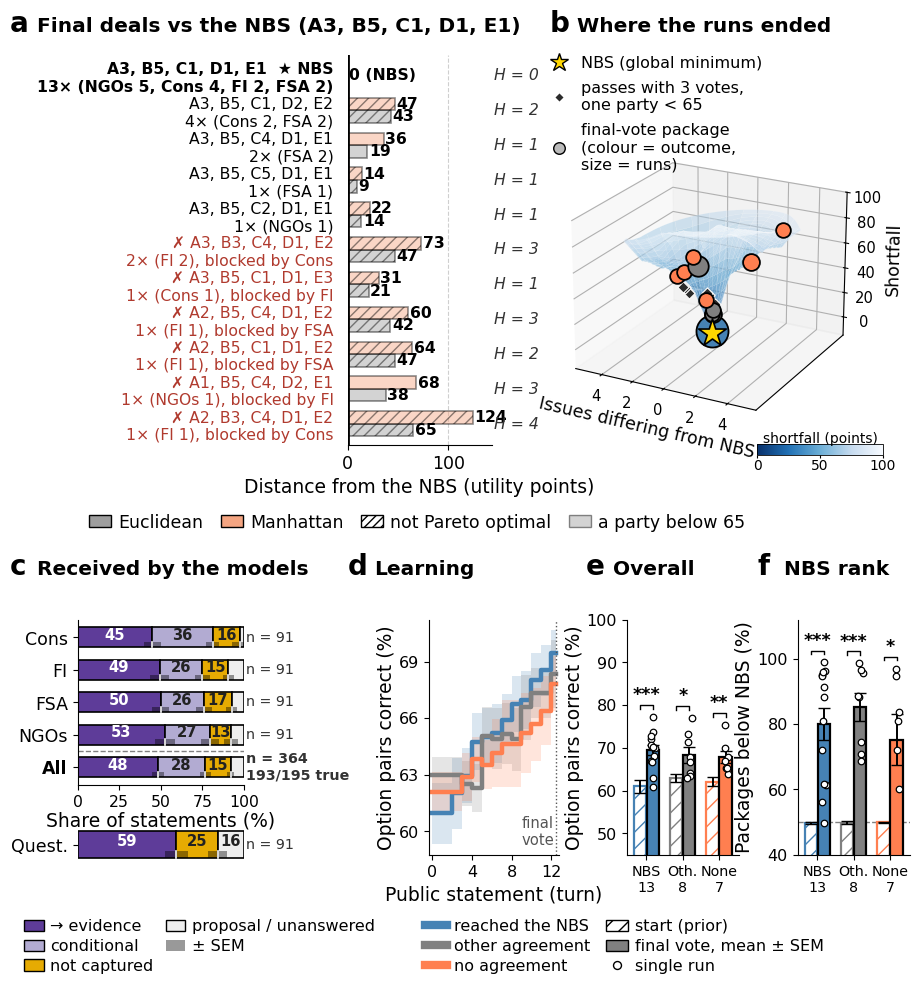

In [20]:
SPEAKERS = ['Consumers', 'Food industry', 'Food Safety Authorities', 'Environmental NGOs']
landscape = landscape_data(TRUE, NBS, CATALOG)
paths = run_paths(finished, NBS, landscape['idx'], outcome_label)
final_deals, final_deal_runs, deal_info = final_deals_table(finished, TRUE)
final_deals.to_csv(OUT2 / 'figure2_final_deals.csv', index=False)
apply_palette(COLORS)
apply_fonts(FONTS)
fig = make_figure_2row(final_deals, deal_info, statements, evidence, questions, kt, se, se_tests, landscape, paths, NBS,
                       SPEAKERS, elev=VIEW_ELEV, azim=VIEW_AZIM)
for ext in ('png', 'pdf'):
    fig.savefig(OUT2 / f'Figure2_outcomes_and_perception.{ext}', dpi=300)
print('Saved', OUT2 / 'Figure2_outcomes_and_perception.png')
plt.show()

## Download all outputs

In [ ]:
bundle = shutil.make_archive(str(Path(OUT_DIR)), 'zip', OUT_DIR)
print('Saved:', bundle)
try:
    from google.colab import files as colab_files
    colab_files.download(bundle)
except ImportError:
    pass